# DATA MINING - GESTION PROACTIVE DES RISQUES DE CARTHAGE ASSURANCE

**Auteurs :** Zouhour Ameur, Melek Rekik, Ons Yangui, Moataz Triki

**Objectif :** Développer un modèle prédictif pour identifier les facteurs de risque d'assurance.

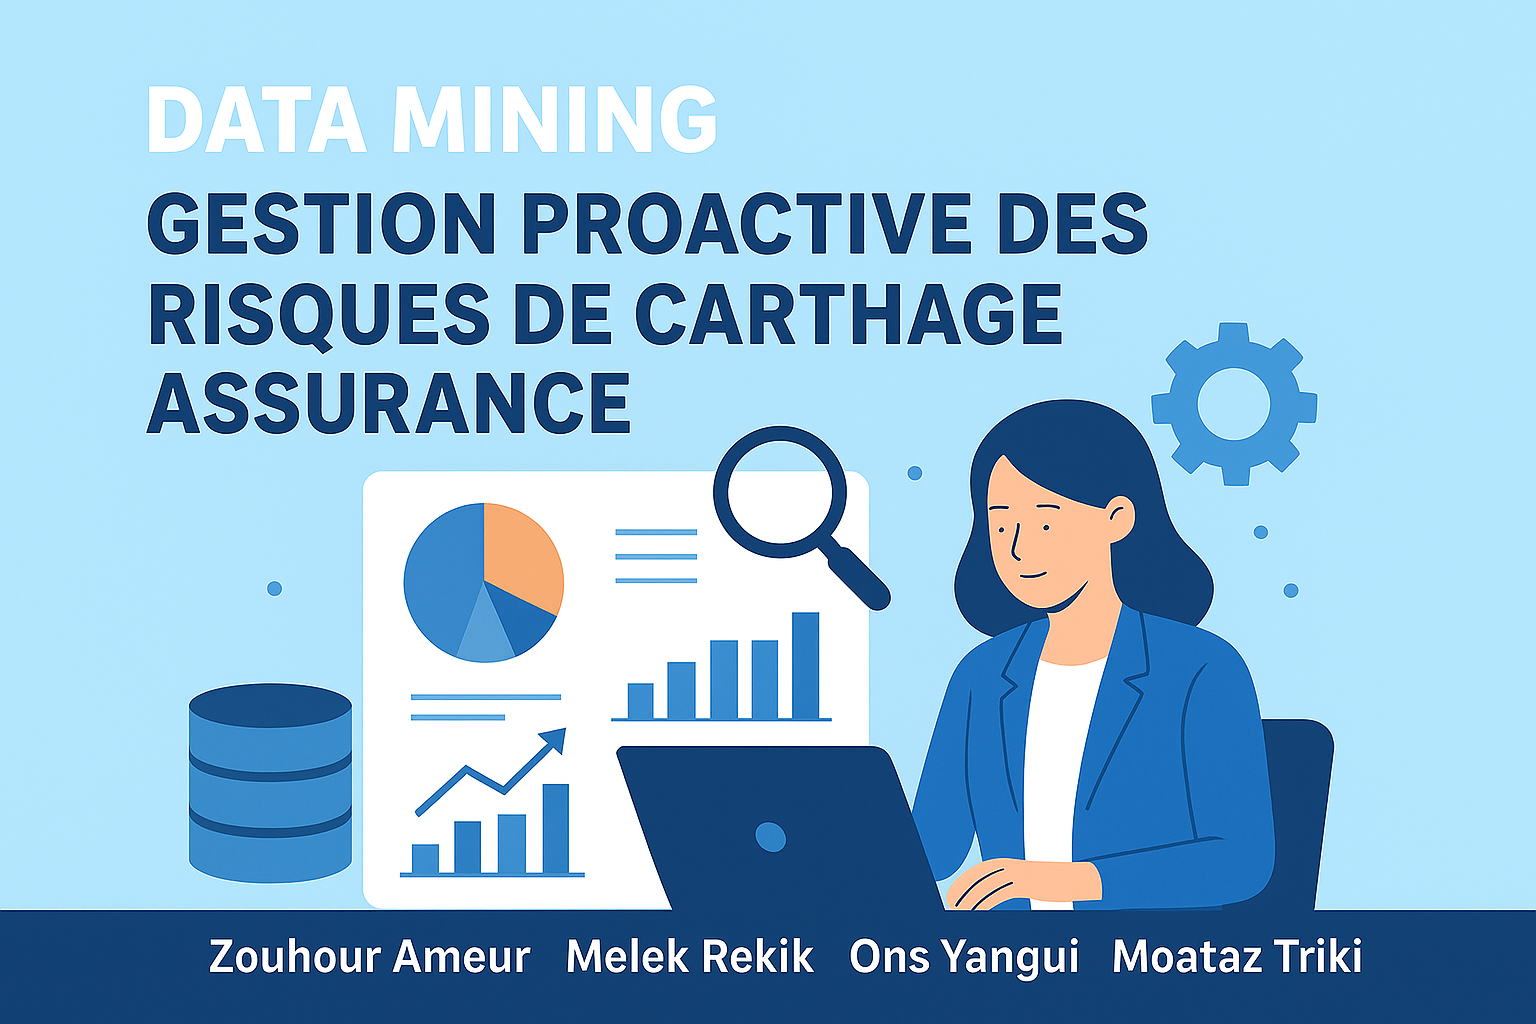

## 📥 ÉTAPE 1 : CHARGEMENT DES DONNÉES

### 1.1 Importation des bibliothèques
Importation des librairies nécessaires pour l'analyse et la modélisation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, KBinsDiscretizer, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_curve, roc_auc_score, precision_score, 
                             recall_score, f1_score, accuracy_score)
from sklearn.calibration import CalibratedClassifierCV

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


### 1.2 Chargement des données d'entraînement
Chargement du dataset principal avec 5014 observations et 13 variables.

In [5]:
df_train = pd.read_excel("insurance.xlsx")
print(f"✅ Données d'entraînement chargées: {len(df_train)} observations, {len(df_train.columns)} colonnes")
print(f"Premières lignes:")
df_train.head()

✅ Données d'entraînement chargées: 5014 observations, 13 colonnes
Premières lignes:


,policy_id,year,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,risk_score,Geo_Code,claim
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,H13501,2012.0,1.0,1.0,N/V,V,U,1240.0,Wood-framed,without,NaN,75117,non
3,H14962,2012.0,1.0,0.0,N/V,V,U,900.0,Non-combustible,without,NaN,62916,non
4,H17755,2013.0,1.0,1.0,V/N,O,R,4984.0,Non-combustible,4,NaN,31149,oui


### 1.3 Chargement des données de test
Chargement du dataset de test avec 2147 observations. **Note :** La colonne `risk_score` est présente dans le test mais vide dans le train → incohérence à traiter.

In [7]:
df_test = pd.read_excel("insurance.xlsx", sheet_name=1)
print(f"✅ Données de test chargées: {len(df_test)} observations, {len(df_test.columns)} colonnes")
print(f"Premières lignes:")
df_test.head()

✅ Données de test chargées: 2147 observations, 13 colonnes
Premières lignes:


,policy_id,year,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,risk_score,Geo_Code,claim
0,H3733,2013,1.0,0,V/V,V,U,3760.0,Fire-resistive,without,0.72,43157,oui
1,H16909,2015,1.0,0,V/N,O,R,1452.0,Fire-resistive,5,0.45,58194,non
2,H16867,2013,1.0,1,V/N,O,R,1944.0,Ordinary,6,0.79,92050,oui
3,H14813,2015,1.0,0,N/V,V,U,2270.0,Non-combustible,without,0.66,13209,oui
4,H3728,2016,0.5,0,V/N,O,R,2976.0,Fire-resistive,9,0.18,5177,non


## 🔍 ÉTAPE 2 : ANALYSE EXPLORATOIRE (EDA)

### 2.1 Structure des données
Analyse des types de données, dimensions et valeurs manquantes.

**Insight :** `risk_score` a 0 valeur non-nulle dans le train → à supprimer.

In [9]:
print("=== STRUCTURE DES DONNÉES D'ENTRAÎNEMENT ===")
print(df_train.info())
print("\n" + "="*50)

=== STRUCTURE DES DONNÉES D'ENTRAÎNEMENT ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5014 entries, 0 to 5013
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policy_id               5012 non-null   object 
 1   year                    5012 non-null   float64
 2   coverage_period         5012 non-null   float64
 3   is_residential          5012 non-null   float64
 4   is_finished_and_fenced  5012 non-null   object 
 5   has_garden              5008 non-null   object 
 6   locality                5012 non-null   object 
 7   area_m2                 4935 non-null   float64
 8   structure_type          5012 non-null   object 
 9   window_count            5012 non-null   object 
 10  risk_score              0 non-null      float64
 11  Geo_Code                4939 non-null   object 
 12  claim                   5012 non-null   object 
dtypes: float64(5), object(8)
memory usage: 509.4+ KB

### 2.2 Structure des données de test
Analyse de la cohérence avec le jeu d'entraînement.

In [11]:
print("=== STRUCTURE DES DONNÉES DE TEST ===")
print(df_test.info())
print("\n" + "="*50)

=== STRUCTURE DES DONNÉES DE TEST ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2147 entries, 0 to 2146
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policy_id               2147 non-null   object 
 1   year                    2147 non-null   int64  
 2   coverage_period         2147 non-null   float64
 3   is_residential          2147 non-null   int64  
 4   is_finished_and_fenced  2147 non-null   object 
 5   has_garden              2144 non-null   object 
 6   locality                2147 non-null   object 
 7   area_m2                 2118 non-null   float64
 8   structure_type          2147 non-null   object 
 9   window_count            2147 non-null   object 
 10  risk_score              2147 non-null   float64
 11  Geo_Code                2118 non-null   object 
 12  claim                   2147 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 218.2+

### 2.3 Statistiques descriptives - Train
Analyse des distributions et déséquilibres.

**Insight :** Variable `claim` déséquilibrée (77.5% "non", 22.5% "oui").

In [13]:
print("=== STATISTIQUES DESCRIPTIVES - DONNÉES D'ENTRAÎNEMENT ===")
print(df_train.describe(include="all"))
print("\n" + "="*50)

=== STATISTIQUES DESCRIPTIVES - DONNÉES D'ENTRAÎNEMENT ===
       policy_id         year  coverage_period  is_residential  \
count       5012  5012.000000      5012.000000     5012.000000   
unique      5012          NaN              NaN             NaN   
top       H13501          NaN              NaN             NaN   
freq           1          NaN              NaN             NaN   
mean         NaN  2013.660215         0.869713        0.301077   
std          NaN     1.383134         0.219496        0.458772   
min          NaN  2012.000000         0.500000        0.000000   
25%          NaN  2012.000000         0.500000        0.000000   
50%          NaN  2013.000000         1.000000        0.000000   
75%          NaN  2015.000000         1.000000        1.000000   
max          NaN  2016.000000         1.000000        1.000000   

       is_finished_and_fenced has_garden locality       area_m2  \
count                    5012       5008     5012   4935.000000   
unique        

### 2.4 Statistiques descriptives - Test
Vérification de la similarité des distributions avec le train.

In [15]:
print("=== STATISTIQUES DESCRIPTIVES - DONNÉES DE TEST ===")
print(df_test.describe(include="all"))
print("\n" + "="*50)

=== STATISTIQUES DESCRIPTIVES - DONNÉES DE TEST ===
       policy_id         year  coverage_period  is_residential  \
count       2147  2147.000000      2147.000000     2147.000000   
unique      2147          NaN              NaN             NaN   
top        H3733          NaN              NaN             NaN   
freq           1          NaN              NaN             NaN   
mean         NaN  2013.691197         0.876805        0.315789   
std          NaN     1.385631         0.215504        0.464938   
min          NaN  2012.000000         0.500000        0.000000   
25%          NaN  2012.000000         1.000000        0.000000   
50%          NaN  2013.000000         1.000000        0.000000   
75%          NaN  2015.000000         1.000000        1.000000   
max          NaN  2016.000000         1.000000        1.000000   

       is_finished_and_fenced has_garden locality       area_m2  \
count                    2147       2144     2147   2118.000000   
unique               

### 2.5 Valeurs manquantes - Train
Identification des colonnes avec valeurs manquantes.

**Problèmes :** `area_m2` (79), `Geo_Code` (75), `has_garden` (6).

In [17]:
print("=== VALEURS MANQUANTES - DONNÉES D'ENTRAÎNEMENT ===")
print(f"Total valeurs manquantes: {df_train.isnull().sum().sum()}")
print("\nRépartition par colonne:")
print(df_train.isnull().sum())
print("\n" + "="*50)

=== VALEURS MANQUANTES - DONNÉES D'ENTRAÎNEMENT ===
Total valeurs manquantes: 5192

Répartition par colonne:
policy_id                    2
year                         2
coverage_period              2
is_residential               2
is_finished_and_fenced       2
has_garden                   6
locality                     2
area_m2                     79
structure_type               2
window_count                 2
risk_score                5014
Geo_Code                    75
claim                        2
dtype: int64



### 2.6 Valeurs manquantes - Test
**Problèmes :** `area_m2` (29), `Geo_Code` (29), `has_garden` (3).

In [19]:
print("=== VALEURS MANQUANTES - DONNÉES DE TEST ===")
print(f"Total valeurs manquantes: {df_test.isnull().sum().sum()}")
print("\nRépartition par colonne:")
print(df_test.isnull().sum())
print("\n" + "="*50)

=== VALEURS MANQUANTES - DONNÉES DE TEST ===
Total valeurs manquantes: 61

Répartition par colonne:
policy_id                  0
year                       0
coverage_period            0
is_residential             0
is_finished_and_fenced     0
has_garden                 3
locality                   0
area_m2                   29
structure_type             0
window_count               0
risk_score                 0
Geo_Code                  29
claim                      0
dtype: int64



### 2.7 Corrélations - Train
Analyse des relations entre variables numériques.

**Insight :** Pas de corrélations fortes entre les prédicteurs.

=== MATRICE DE CORRÉLATION - DONNÉES D'ENTRAÎNEMENT ===


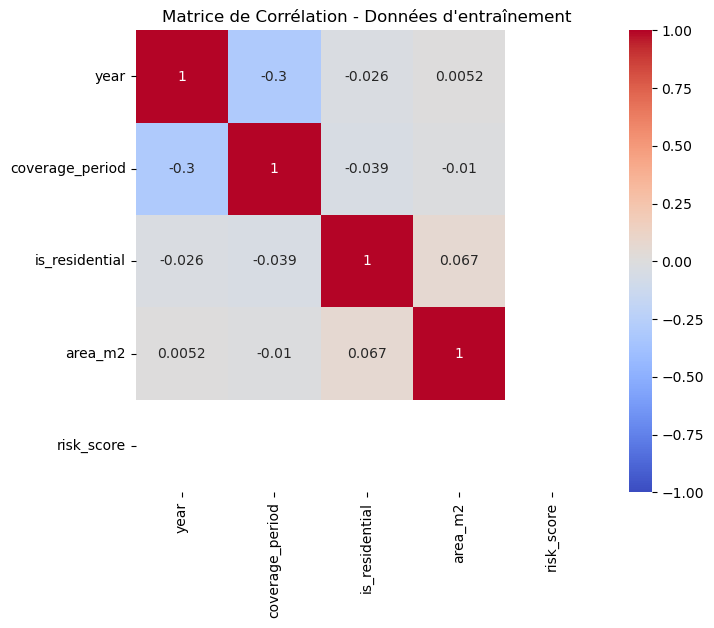

In [21]:
print("=== MATRICE DE CORRÉLATION - DONNÉES D'ENTRAÎNEMENT ===")
corr_train = df_train.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_train, annot=True, vmin=-1, vmax=1, cmap='coolwarm', square=True)
plt.title("Matrice de Corrélation - Données d'entraînement")
plt.show()

### 2.8 Corrélations - Test
Vérification de la cohérence des corrélations.

=== MATRICE DE CORRÉLATION - DONNÉES DE TEST ===


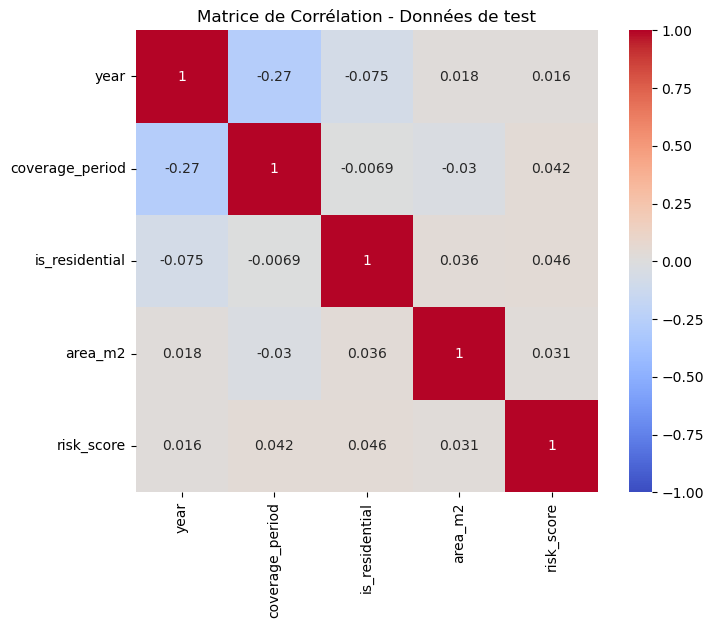

In [23]:
print("=== MATRICE DE CORRÉLATION - DONNÉES DE TEST ===")
corr_test = df_test.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_test, annot=True, vmin=-1, vmax=1, cmap='coolwarm', square=True)
plt.title("Matrice de Corrélation - Données de test")
plt.show()

### 2.9 Distribution de area_m2
Analyse de la distribution des surfaces par type de propriété.

**Observation :** Différences notables entre résidentiel et commercial.

=== DISTRIBUTION DE AREA_M2 PAR TYPE DE RÉSIDENCE ===


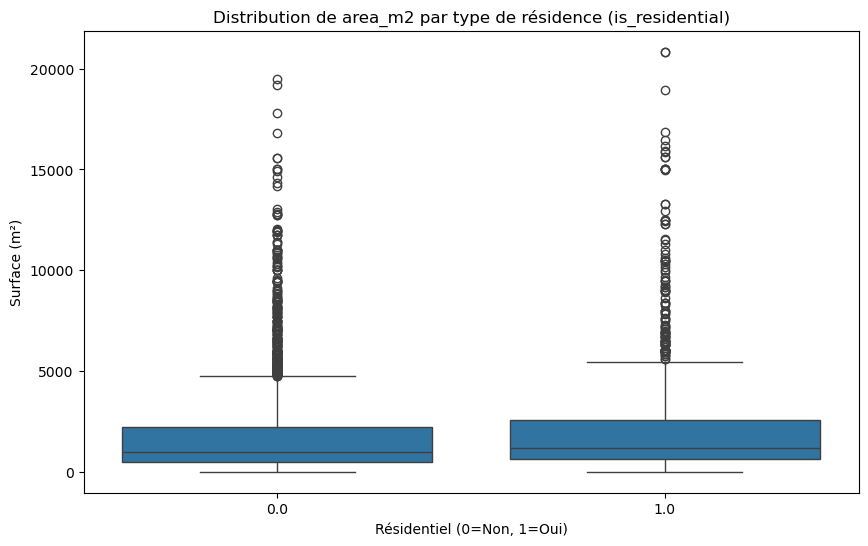

In [25]:
print("=== DISTRIBUTION DE AREA_M2 PAR TYPE DE RÉSIDENCE ===")
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_residential', y='area_m2', data=df_train)
plt.title("Distribution de area_m2 par type de résidence (is_residential)")
plt.xlabel("Résidentiel (0=Non, 1=Oui)")
plt.ylabel("Surface (m²)")
plt.show()

### 2.10 Distributions catégorielles - Train
Visualisation des variables qualitatives.

**Observation :** `locality` et `has_garden` sont parfaitement corrélés (U→V, R→0).

=== DISTRIBUTION DES VARIABLES CATÉGORIELLES - TRAIN ===


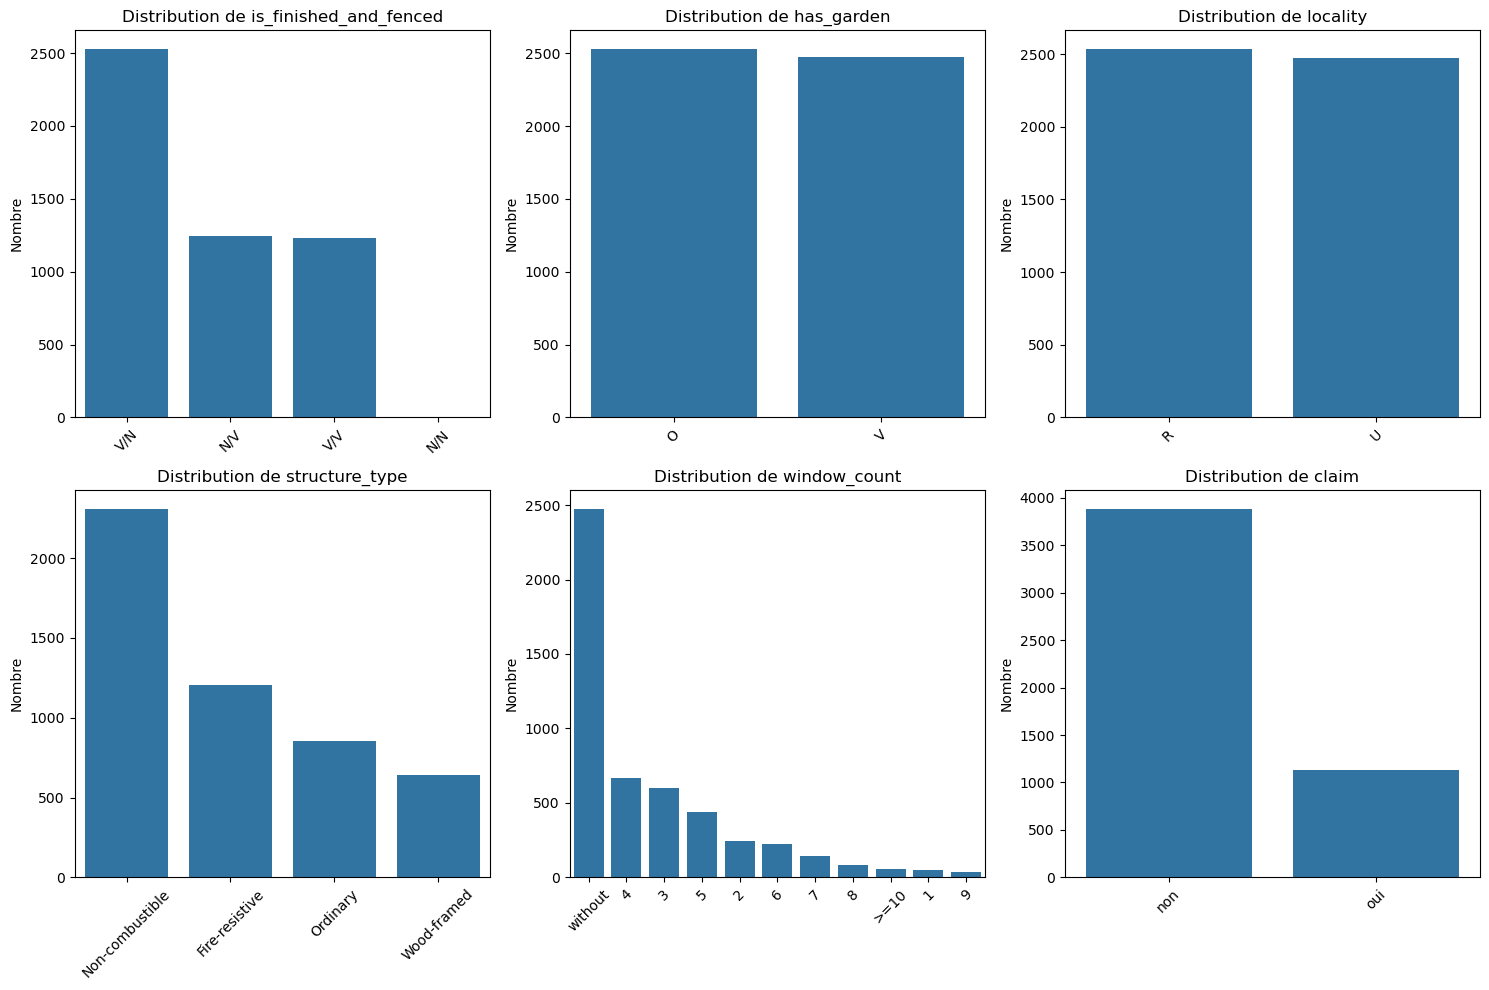

In [27]:
print("=== DISTRIBUTION DES VARIABLES CATÉGORIELLES - TRAIN ===")
categorical_vars = ['is_finished_and_fenced', 'has_garden', 'locality', 
                   'structure_type', 'window_count', 'claim']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(categorical_vars):
    if i < len(axes):
        sns.countplot(x=var, data=df_train, ax=axes[i], order=df_train[var].value_counts().index)
        axes[i].set_title(f'Distribution de {var}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Nombre')

plt.tight_layout()
plt.show()

### 2.11 Distributions catégorielles - Test
Vérification de la cohérence des distributions.

=== DISTRIBUTION DES VARIABLES CATÉGORIELLES - TEST ===


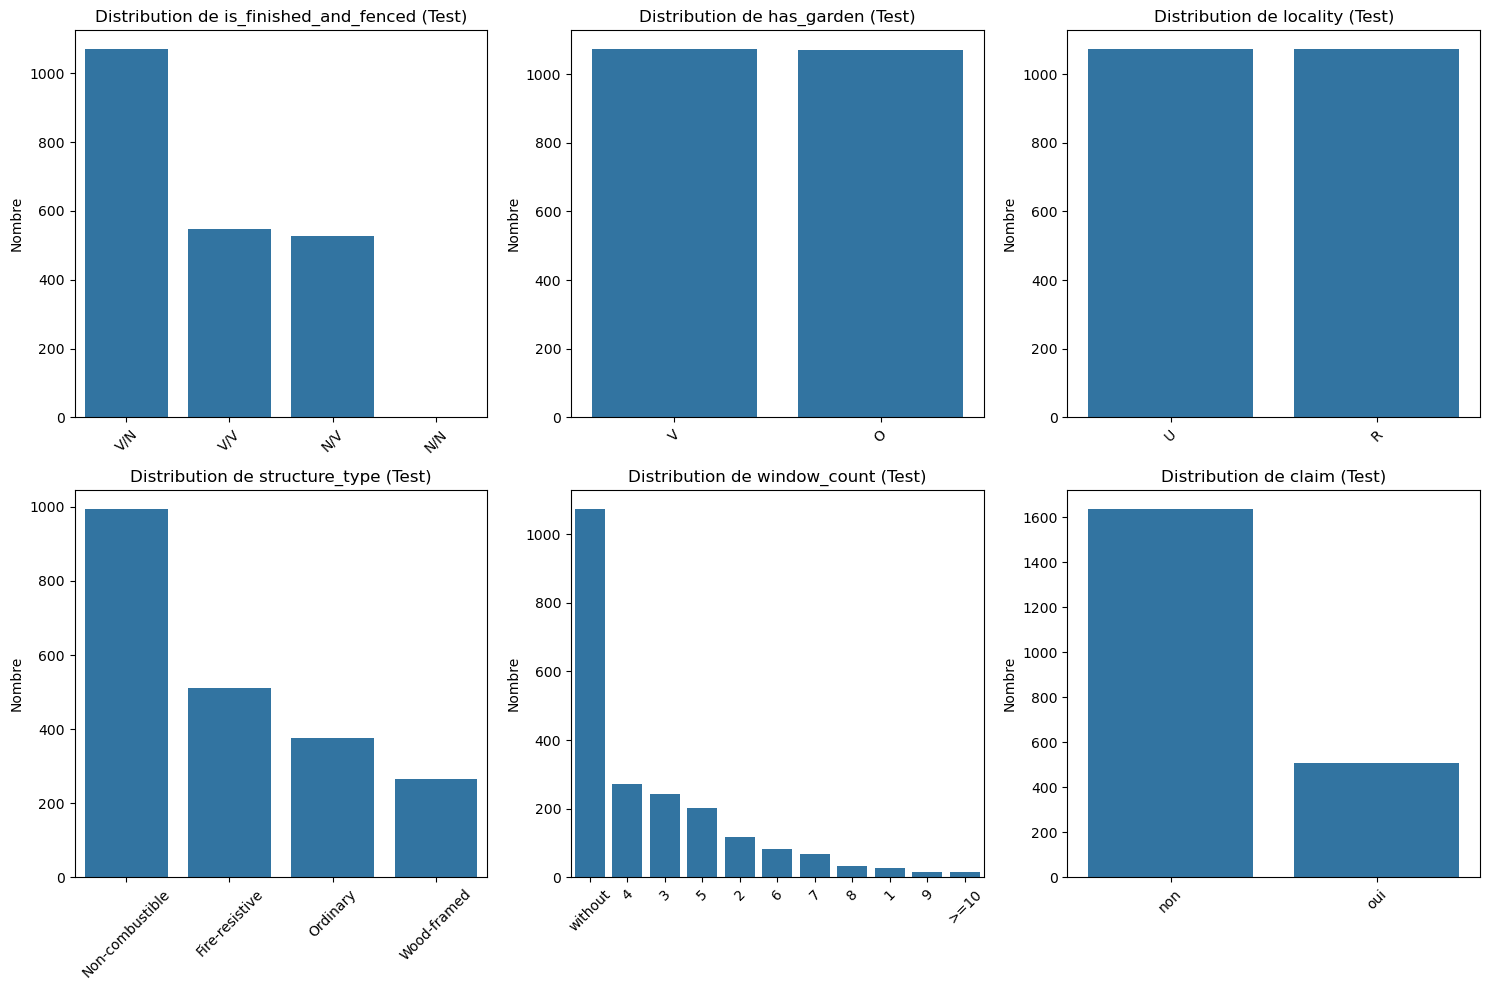

In [29]:
print("=== DISTRIBUTION DES VARIABLES CATÉGORIELLES - TEST ===")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(categorical_vars):
    if i < len(axes):
        sns.countplot(x=var, data=df_test, ax=axes[i], order=df_test[var].value_counts().index)
        axes[i].set_title(f'Distribution de {var} (Test)')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Nombre')

plt.tight_layout()
plt.show()

## 🧹 ÉTAPE 3 : NETTOYAGE DES DONNÉES

### 3.1 Suppression des colonnes vides - Train
Suppression des colonnes 100% vides (`risk_score`).

In [31]:
print("=== SUPPRESSION DES COLONNES VIDES - TRAIN ===")
print(f"Dimensions avant: {df_train.shape}")
df_train = df_train.dropna(axis=1, how='all')
print(f"Dimensions après: {df_train.shape}")
print("✅ Colonnes entièrement vides supprimées")

=== SUPPRESSION DES COLONNES VIDES - TRAIN ===
Dimensions avant: (5014, 13)
Dimensions après: (5014, 12)
✅ Colonnes entièrement vides supprimées


### 3.2 Suppression des colonnes vides - Test
Aucune colonne vide détectée.

In [33]:
print("=== SUPPRESSION DES COLONNES VIDES - TEST ===")
print(f"Dimensions avant: {df_test.shape}")
df_test = df_test.dropna(axis=1, how='all')
print(f"Dimensions après: {df_test.shape}")
print("✅ Colonnes entièrement vides supprimées")

=== SUPPRESSION DES COLONNES VIDES - TEST ===
Dimensions avant: (2147, 13)
Dimensions après: (2147, 13)
✅ Colonnes entièrement vides supprimées


### 3.3 Suppression de risk_score - Test
Suppression pour homogénéiser avec le train.

In [35]:
print("=== SUPPRESSION DE RISK_SCORE - TEST ===")
print(f"Dimensions avant: {df_test.shape}")
if 'risk_score' in df_test.columns:
    df_test.drop(columns=["risk_score"], inplace=True)
    print(f"Dimensions après: {df_test.shape}")
    print("✅ Colonne risk_score supprimée (incohérence avec le train)")
else:
    print("❌ La colonne risk_score n'existe pas dans le test")

=== SUPPRESSION DE RISK_SCORE - TEST ===
Dimensions avant: (2147, 13)
Dimensions après: (2147, 12)
✅ Colonne risk_score supprimée (incohérence avec le train)


### 3.4 Recherche de doublons - Train
Identification et suppression des lignes dupliquées.

In [37]:
print("=== RECHERCHE DE DOUBLONS - TRAIN ===")
initial_count = len(df_train)
duplicates_count = df_train.duplicated().sum()
print(f"Nombre de doublons trouvés: {duplicates_count}")
if duplicates_count > 0:
    df_train.drop_duplicates(inplace=True, ignore_index=True)
    final_count = len(df_train)
    print(f"Doublons supprimés: {initial_count - final_count}")
else:
    print("✅ Aucun doublon trouvé")
print(f"Dimensions finales: {df_train.shape}")

=== RECHERCHE DE DOUBLONS - TRAIN ===
Nombre de doublons trouvés: 1
Doublons supprimés: 1
Dimensions finales: (5013, 12)


### 3.5 Recherche de doublons - Test
Vérification de l'absence de doublons.

In [39]:
print("=== RECHERCHE DE DOUBLONS - TEST ===")
initial_count = len(df_test)
duplicates_count = df_test.duplicated().sum()
print(f"Nombre de doublons trouvés: {duplicates_count}")
if duplicates_count > 0:
    df_test.drop_duplicates(inplace=True, ignore_index=True)
    final_count = len(df_test)
    print(f"Doublons supprimés: {initial_count - final_count}")
else:
    print("✅ Aucun doublon trouvé")
print(f"Dimensions finales: {df_test.shape}")

=== RECHERCHE DE DOUBLONS - TEST ===
Nombre de doublons trouvés: 0
✅ Aucun doublon trouvé
Dimensions finales: (2147, 12)


### 3.6 Séparation variables numériques/catégorielles
Identification automatique des types de variables.

In [41]:
print("=== SÉPARATION DES VARIABLES NUMÉRIQUES ET CATÉGORIELLES ===")
l_num = list(df_train.select_dtypes(exclude="object").columns)
l_cat = list(df_train.select_dtypes(include="object").columns)

print(f"Variables numériques ({len(l_num)}): {l_num}")
print(f"Variables catégorielles ({len(l_cat)}): {l_cat}")

=== SÉPARATION DES VARIABLES NUMÉRIQUES ET CATÉGORIELLES ===
Variables numériques (4): ['year', 'coverage_period', 'is_residential', 'area_m2']
Variables catégorielles (8): ['policy_id', 'is_finished_and_fenced', 'has_garden', 'locality', 'structure_type', 'window_count', 'Geo_Code', 'claim']


### 3.7 Suppression lignes entièrement vides
Nettoyage des lignes sans aucune donnée.

In [43]:
print("=== SUPPRESSION DES LIGNES ENTIÈREMENT VIDES - TRAIN ===")
initial_count = len(df_train)
df_train.dropna(how="all", inplace=True)
final_count = len(df_train)

if initial_count > final_count:
    print(f"✅ Lignes supprimées: {initial_count - final_count}")
else:
    print("✅ Aucune ligne entièrement vide trouvée")
print(f"Valeurs manquantes totales: {df_train.isnull().sum().sum()}")

=== SUPPRESSION DES LIGNES ENTIÈREMENT VIDES - TRAIN ===
✅ Lignes supprimées: 1
Valeurs manquantes totales: 154


### 3.8 Imputation conditionnelle de area_m2 - Train
Imputation par médiane selon `is_residential`.

In [45]:
print("=== IMPUTATION CONDITIONNELLE DE AREA_M2 - TRAIN ===")
print(f"Valeurs manquantes avant: {df_train['area_m2'].isnull().sum()}")

# Calcul des médianes par type de résidence
median_area_0 = df_train[df_train['is_residential'] == 0]['area_m2'].median()
median_area_1 = df_train[df_train['is_residential'] == 1]['area_m2'].median()

print(f"Médiane area_m2 pour is_residential=0: {median_area_0}")
print(f"Médiane area_m2 pour is_residential=1: {median_area_1}")

# Imputation conditionnelle
df_train['area_m2'] = df_train.apply(
    lambda row: median_area_0 if pd.isna(row['area_m2']) and row['is_residential'] == 0 
    else (median_area_1 if pd.isna(row['area_m2']) and row['is_residential'] == 1 
          else row['area_m2']), axis=1
)

print(f"Valeurs manquantes après: {df_train['area_m2'].isnull().sum()}")
print("✅ Imputation conditionnelle terminée")

=== IMPUTATION CONDITIONNELLE DE AREA_M2 - TRAIN ===
Valeurs manquantes avant: 77
Médiane area_m2 pour is_residential=0: 1000.0
Médiane area_m2 pour is_residential=1: 1200.0
Valeurs manquantes après: 0
✅ Imputation conditionnelle terminée


### 3.9 Imputation conditionnelle de area_m2 - Test
Application de la même méthode.

In [47]:
print("=== IMPUTATION CONDITIONNELLE DE AREA_M2 - TEST ===")
print(f"Valeurs manquantes avant: {df_test['area_m2'].isnull().sum()}")

# Utilisation des mêmes médianes calculées sur le train
df_test['area_m2'] = df_test.apply(
    lambda row: median_area_0 if pd.isna(row['area_m2']) and row['is_residential'] == 0 
    else (median_area_1 if pd.isna(row['area_m2']) and row['is_residential'] == 1 
          else row['area_m2']), axis=1
)

print(f"Valeurs manquantes après: {df_test['area_m2'].isnull().sum()}")
print("✅ Imputation conditionnelle terminée")

=== IMPUTATION CONDITIONNELLE DE AREA_M2 - TEST ===
Valeurs manquantes avant: 29
Valeurs manquantes après: 0
✅ Imputation conditionnelle terminée


### 3.10 Imputation intelligente de has_garden
Imputation basée sur `locality` (U→V, R→0).

In [49]:
print("=== IMPUTATION INTELLIGENTE DE HAS_GARDEN ===")

# Vérification avant imputation
print(f"Valeurs manquantes dans has_garden (train) AVANT: {df_train['has_garden'].isnull().sum()}")
print(f"Valeurs manquantes dans has_garden (test) AVANT: {df_test['has_garden'].isnull().sum()}")

# Analyse de la relation entre locality et has_garden
print("\nAnalyse de la relation locality-has_garden:")
print("Train:")
print(pd.crosstab(df_train['locality'], df_train['has_garden'], normalize='index'))
print("\nTest:")
print(pd.crosstab(df_test['locality'], df_test['has_garden'], normalize='index'))

# Imputation basée sur locality (U → 'V', R → '0')
df_train['has_garden'] = df_train['has_garden'].fillna(
    df_train['locality'].map({'U': 'V', 'R': '0'})
)

df_test['has_garden'] = df_test['has_garden'].fillna(
    df_test['locality'].map({'U': 'V', 'R': '0'})
)

print(f"\nValeurs manquantes dans has_garden (train) APRÈS: {df_train['has_garden'].isnull().sum()}")
print(f"Valeurs manquantes dans has_garden (test) APRÈS: {df_test['has_garden'].isnull().sum()}")
print("✅ Imputation basée sur locality terminée")

=== IMPUTATION INTELLIGENTE DE HAS_GARDEN ===
Valeurs manquantes dans has_garden (train) AVANT: 4
Valeurs manquantes dans has_garden (test) AVANT: 3

Analyse de la relation locality-has_garden:
Train:
has_garden         O         V
locality                      
R           0.999605  0.000395
U           0.000000  1.000000

Test:
has_garden    O    V
locality            
R           1.0  0.0
U           0.0  1.0

Valeurs manquantes dans has_garden (train) APRÈS: 0
Valeurs manquantes dans has_garden (test) APRÈS: 0
✅ Imputation basée sur locality terminée


### 3.11 Suppression des variables inutiles
Suppression de `Geo_Code` (haute cardinalité) et `policy_id` (identifiant).

In [51]:
print("=== SUPPRESSION DES VARIABLES INUTILES ===")
print("Dimensions avant suppression:")
print(f"Train: {df_train.shape}, Test: {df_test.shape}")

# Liste des colonnes à supprimer
cols_to_drop = ['Geo_Code', 'policy_id', 'risk_score']

for col in cols_to_drop:
    if col in df_train.columns:
        df_train.drop(columns=[col], inplace=True)
        print(f"  - {col} supprimé du train")
    if col in df_test.columns:
        df_test.drop(columns=[col], inplace=True)
        print(f"  - {col} supprimé du test")

print("\nDimensions après suppression:")
print(f"Train: {df_train.shape}, Test: {df_test.shape}")

=== SUPPRESSION DES VARIABLES INUTILES ===
Dimensions avant suppression:
Train: (5012, 12), Test: (2147, 12)
  - Geo_Code supprimé du train
  - Geo_Code supprimé du test
  - policy_id supprimé du train
  - policy_id supprimé du test

Dimensions après suppression:
Train: (5012, 10), Test: (2147, 10)


### 3.12 Vérification finale des valeurs manquantes
Confirmation que toutes les valeurs manquantes sont traitées.

In [53]:
print("=== VÉRIFICATION FINALE DES VALEURS MANQUANTES ===")
print("\n📊 DONNÉES D'ENTRAÎNEMENT:")
missing_train = df_train.isnull().sum()
print(missing_train[missing_train > 0] if missing_train.sum() > 0 else "✅ Aucune valeur manquante")

print("\n📊 DONNÉES DE TEST:")
missing_test = df_test.isnull().sum()
print(missing_test[missing_test > 0] if missing_test.sum() > 0 else "✅ Aucune valeur manquante")

total_missing_train = df_train.isnull().sum().sum()
total_missing_test = df_test.isnull().sum().sum()

print(f"\n📈 SYNTHÈSE:")
print(f"Total valeurs manquantes - Train: {total_missing_train}")
print(f"Total valeurs manquantes - Test: {total_missing_test}")

if total_missing_train == 0 and total_missing_test == 0:
    print("\n🎉 NETTOYAGE RÉUSSI : Toutes les valeurs manquantes ont été traitées!")
else:
    print("\n⚠️ ATTENTION : Il reste des valeurs manquantes à traiter.")

=== VÉRIFICATION FINALE DES VALEURS MANQUANTES ===

📊 DONNÉES D'ENTRAÎNEMENT:
✅ Aucune valeur manquante

📊 DONNÉES DE TEST:
✅ Aucune valeur manquante

📈 SYNTHÈSE:
Total valeurs manquantes - Train: 0
Total valeurs manquantes - Test: 0

🎉 NETTOYAGE RÉUSSI : Toutes les valeurs manquantes ont été traitées!


## 🔄 ÉTAPE 4 : TRANSFORMATION DES DONNÉES

### 4.1 Distribution de area_m2 après imputation
Visualisation de l'effet de l'imputation.

=== DISTRIBUTION DES SURFACES APRÈS IMPUTATION ===


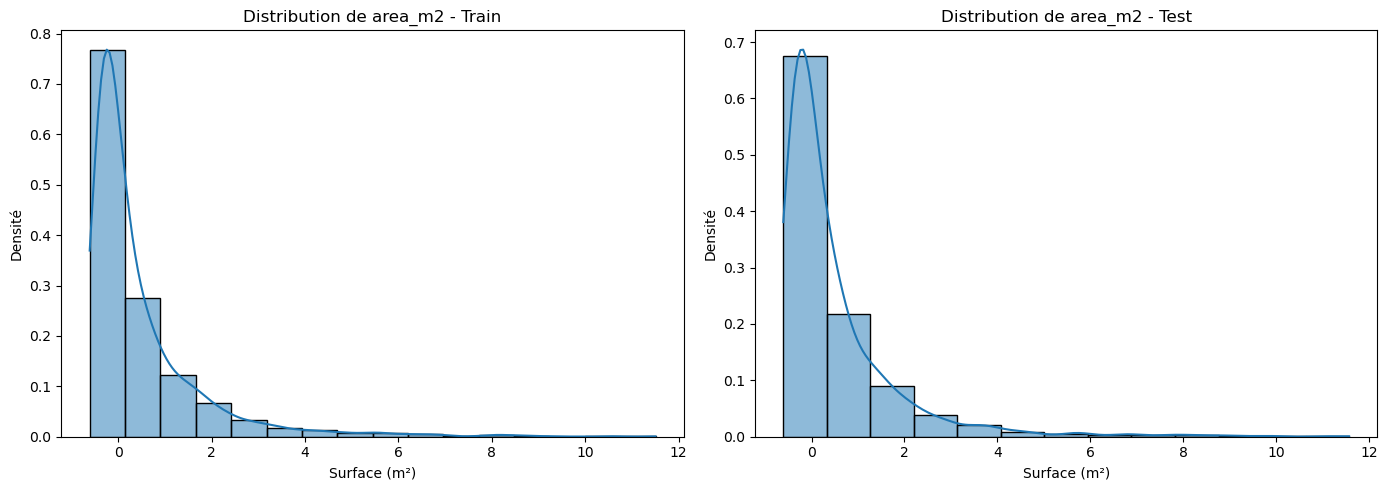

Statistiques area_m2 (train):
count    5012.000000
mean        0.471782
std         1.309315
min        -0.611628
25%        -0.304070
50%         0.000000
75%         0.695930
max        11.504070
Name: area_m2, dtype: float64

Statistiques area_m2 (test):
count    2147.000000
mean        0.485852
std         1.331773
min        -0.606395
25%        -0.297674
50%         0.027326
75%         0.709593
max        11.562209
Name: area_m2, dtype: float64


In [93]:
print("=== DISTRIBUTION DES SURFACES APRÈS IMPUTATION ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
sns.histplot(df_train["area_m2"], kde=True, stat='density', bins=16, ax=axes[0])
axes[0].set_title("Distribution de area_m2 - Train")
axes[0].set_xlabel("Surface (m²)")
axes[0].set_ylabel("Densité")

# Test
sns.histplot(df_test["area_m2"], kde=True, stat='density', bins=13, ax=axes[1])
axes[1].set_title("Distribution de area_m2 - Test")
axes[1].set_xlabel("Surface (m²)")
axes[1].set_ylabel("Densité")

plt.tight_layout()
plt.show()

print(f"Statistiques area_m2 (train):")
print(df_train['area_m2'].describe())
print(f"\nStatistiques area_m2 (test):")
print(df_test['area_m2'].describe())

### 4.2 Normalisation RobustScaler de area_m2
Standardisation robuste aux outliers.

In [57]:
print("=== NORMALISATION ROBUSTSCALER DE AREA_M2 ===")

# Application du RobustScaler (robuste aux outliers)
scaler = RobustScaler()

# Transformation des données d'entraînement
df_train['area_m2'] = scaler.fit_transform(df_train[['area_m2']])

# Transformation des données de test avec le même scaler
df_test['area_m2'] = scaler.transform(df_test[['area_m2']])

print("✅ Normalisation RobustScaler appliquée avec succès!")
print(f"Moyenne area_m2 (train): {df_train['area_m2'].mean():.4f}")
print(f"Écart-type area_m2 (train): {df_train['area_m2'].std():.4f}")
print(f"Moyenne area_m2 (test): {df_test['area_m2'].mean():.4f}")
print(f"Écart-type area_m2 (test): {df_test['area_m2'].std():.4f}")

=== NORMALISATION ROBUSTSCALER DE AREA_M2 ===
✅ Normalisation RobustScaler appliquée avec succès!
Moyenne area_m2 (train): 0.4718
Écart-type area_m2 (train): 1.3093
Moyenne area_m2 (test): 0.4859
Écart-type area_m2 (test): 1.3318


### 4.3 Transformation de window_count
Conversion des valeurs textuelles en numériques ("without"→0, ">=10"→10).

In [60]:
print("=== TRANSFORMATION DE LA VARIABLE WINDOW_COUNT ===")

# Affichage des valeurs uniques avant transformation
print("Valeurs uniques avant transformation:")
print("Train:", df_train["window_count"].unique())
print("Test:", df_test["window_count"].unique())

# Transformation des valeurs textuelles en numériques
mapping = {"without": 0, ">=10": 10}

df_train["window_count"] = df_train["window_count"].replace(mapping)
df_test["window_count"] = df_test["window_count"].replace(mapping)

# Conversion en type numérique
df_train["window_count"] = pd.to_numeric(df_train["window_count"], errors='coerce')
df_test["window_count"] = pd.to_numeric(df_test["window_count"], errors='coerce')

print("\n✅ Transformation de window_count terminée!")
print("Valeurs uniques après transformation:")
print("Train:", sorted(df_train["window_count"].dropna().unique()))
print("Test:", sorted(df_test["window_count"].dropna().unique()))

=== TRANSFORMATION DE LA VARIABLE WINDOW_COUNT ===
Valeurs uniques avant transformation:
Train: ['without' '4' '2' '7' '5' '3' '8' '>=10' '6' '1' '9']
Test: ['without' '5' '6' '9' '7' '3' '8' '4' '1' '2' '>=10']

✅ Transformation de window_count terminée!
Valeurs uniques après transformation:
Train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Test: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


### 4.4 Distribution de l'année (year)
Analyse de la distribution temporelle.

=== DISTRIBUTION DE L'ANNÉE (YEAR) ===


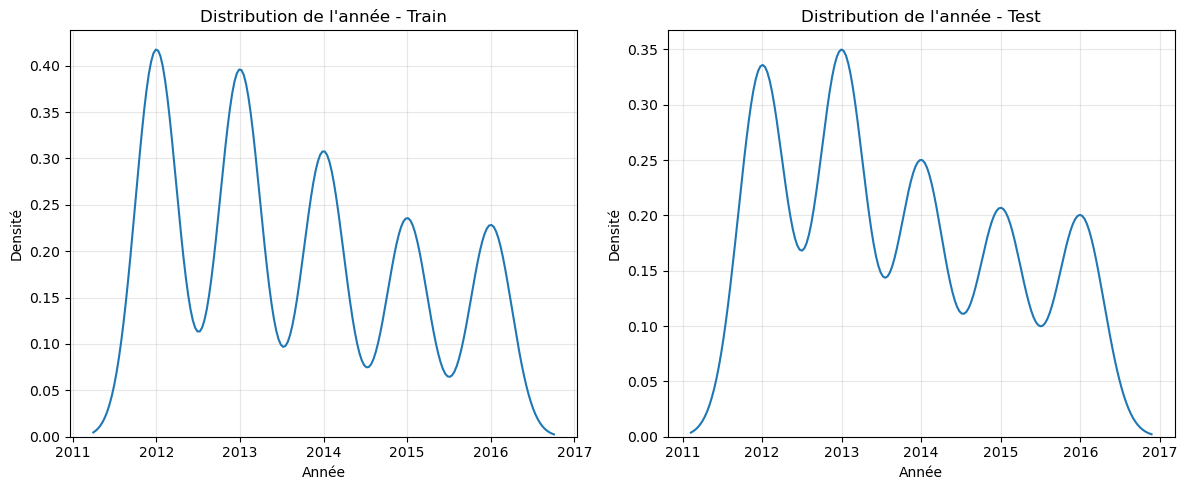

Années uniques (train): [2012.0, 2013.0, 2014.0, 2015.0, 2016.0]
Années uniques (test): [2012, 2013, 2014, 2015, 2016]


In [62]:
print("=== DISTRIBUTION DE L'ANNÉE (YEAR) ===")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train
sns.kdeplot(df_train['year'], bw_method='scott', bw_adjust=1, ax=axes[0])
axes[0].set_title("Distribution de l'année - Train")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Densité")
axes[0].grid(True, alpha=0.3)

# Test
sns.kdeplot(df_test['year'], bw_method='scott', bw_adjust=1, ax=axes[1])
axes[1].set_title("Distribution de l'année - Test")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Densité")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Années uniques (train): {sorted(df_train['year'].unique())}")
print(f"Années uniques (test): {sorted(df_test['year'].unique())}")

### 4.5 Discrétisation de la variable année
Transformation en variable catégorielle ordinale (5 intervalles).

In [64]:
print("=== DISCRÉTISATION DE LA VARIABLE ANNÉE (YEAR) ===")

# Transformation en variable catégorielle ordinale (5 intervalles)
enc_k = KBinsDiscretizer(
    n_bins=5, 
    encode='ordinal', 
    strategy='quantile', 
    subsample=len(df_train),
    random_state=42
)

# Application sur le train
df_train['year'] = enc_k.fit_transform(df_train[['year']])

# Application sur le test avec le même encodeur
df_test['year'] = enc_k.transform(df_test[['year']])

print("✅ Discrétisation de l'année terminée!")
print(f"Valeurs uniques dans year (train): {sorted(df_train['year'].unique())}")
print(f"Valeurs uniques dans year (test): {sorted(df_test['year'].unique())}")
print(f"Distribution (train):\n{df_train['year'].value_counts().sort_index()}")
print(f"Distribution (test):\n{df_test['year'].value_counts().sort_index()}")

=== DISCRÉTISATION DE LA VARIABLE ANNÉE (YEAR) ===
✅ Discrétisation de l'année terminée!
Valeurs uniques dans year (train): [0.0, 1.0, 2.0, 3.0]
Valeurs uniques dans year (test): [0.0, 1.0, 2.0, 3.0]
Distribution (train):
year
0.0    1320
1.0    1252
2.0     973
3.0    1467
Name: count, dtype: int64
Distribution (test):
year
0.0    538
1.0    559
2.0    399
3.0    651
Name: count, dtype: int64


### 4.6 Encodage ordinal des variables catégorielles
Conversion de toutes les variables catégorielles en format numérique.

In [66]:
print("=== ENCODAGE ORDINAL DES VARIABLES CATÉGORIELLES ===")

# Liste des variables catégorielles à encoder
cat_cols = ["is_finished_and_fenced", "has_garden", "locality", 
            "structure_type", "claim"]

print(f"Variables à encoder: {cat_cols}")

# Création et application de l'encodeur ordinal
enc_o = OrdinalEncoder()

# Encodage des données d'entraînement
df_train[cat_cols] = enc_o.fit_transform(df_train[cat_cols])

# Encodage des données de test avec le même encodeur
df_test[cat_cols] = enc_o.transform(df_test[cat_cols])

print("✅ Encodage ordinal terminé!")
print("\nExemple des premières lignes (train):")
print(df_train[cat_cols].head())
print("\nValeurs encodées pour chaque variable:")
for col in cat_cols:
    print(f"{col}: {sorted(df_train[col].unique())}")

=== ENCODAGE ORDINAL DES VARIABLES CATÉGORIELLES ===
Variables à encoder: ['is_finished_and_fenced', 'has_garden', 'locality', 'structure_type', 'claim']
✅ Encodage ordinal terminé!

Exemple des premières lignes (train):
   is_finished_and_fenced  has_garden  locality  structure_type  claim
1                     1.0         2.0       1.0             3.0    0.0
2                     1.0         2.0       1.0             1.0    0.0
3                     2.0         1.0       0.0             1.0    1.0
4                     1.0         2.0       1.0             3.0    1.0
5                     1.0         2.0       1.0             1.0    0.0

Valeurs encodées pour chaque variable:
is_finished_and_fenced: [0.0, 1.0, 2.0, 3.0]
has_garden: [0.0, 1.0, 2.0]
locality: [0.0, 1.0]
structure_type: [0.0, 1.0, 2.0, 3.0]
claim: [0.0, 1.0]


### 4.7 Analyse de la variance
Identification des variables à faible variance (peu informatives).

In [68]:
print("=== ANALYSE DE LA VARIANCE ===")

# Calcul de la variance pour chaque variable
variances = df_train.var()
print("Variances des variables:")
for var, var_value in variances.items():
    print(f"  {var}: {var_value:.6f}")

# Sélection par seuil de variance
thresholder = VarianceThreshold(threshold=0.001)

# Variables à analyser (exclure la variable cible 'claim')
features_to_analyze = [col for col in df_train.columns if col != 'claim']

# Application de la sélection
data_high_variance = thresholder.fit_transform(df_train[features_to_analyze])

print(f"\nDimensions avant sélection: {df_train[features_to_analyze].shape}")
print(f"Dimensions après sélection: {data_high_variance.shape}")

# Vérification des features sélectionnées
selected_features = thresholder.get_feature_names_out(features_to_analyze)
print(f"\n✅ Features sélectionnées ({len(selected_features)}):")
print(list(selected_features))

# Application sur les données de test
data_high_variance_test = thresholder.transform(df_test[features_to_analyze])
print(f"\n✅ Transformation appliquée aux données de test")

=== ANALYSE DE LA VARIANCE ===
Variances des variables:
  year: 1.362141
  coverage_period: 0.048178
  is_residential: 0.210472
  is_finished_and_fenced: 0.498286
  has_garden: 0.251600
  locality: 0.250012
  area_m2: 1.714307
  structure_type: 0.889358
  window_count: 6.429213
  claim: 0.174223

Dimensions avant sélection: (5012, 9)
Dimensions après sélection: (5012, 9)

✅ Features sélectionnées (9):
['year', 'coverage_period', 'is_residential', 'is_finished_and_fenced', 'has_garden', 'locality', 'area_m2', 'structure_type', 'window_count']

✅ Transformation appliquée aux données de test


# Justification du choix du seuil de variance

## Pourquoi un seuil de 0.001 ?

### 1. Objectif principal
Éliminer uniquement les variables **constantes ou quasi-constantes** qui n'apportent aucune information pour la modélisation.

### 2. Équilibre recherché
- **Trop élevé (> 0.01)** : Risque de supprimer des variables informatives comme `coverage_period` (0.048)
- **Trop bas (< 0.0001)** : Ne filtrerait aucune variable, même les constantes
- **0.001** : Point d'équilibre optimal

### 3. Cas critique : `coverage_period`
- Variance = 0.048
- Malgré sa faible variance, cette variable est potentiellement importante pour prédire les réclamations
- Avec un seuil à 0.05, elle serait éliminée → perteil de 0.001 adapté

## Validation du choix
Le fait qu'aucune variable n'ait été éliminée confirme :
- Notre dataset ne contient pas de variables constantes
- Toutes les variables présentent une variabilité minimale
- Le seuil était assez permissif pourtuels artefacts de données.e variable supprimée

### 4.8 Matrice de corrélation avancée
Analyse complète des relations entre toutes les variables.

=== MATRICE DE CORRÉLATION AVANCÉE ===
=== MATRICE DE CORRÉLATION - DONNÉES D'ENTRAÎNEMENT ===



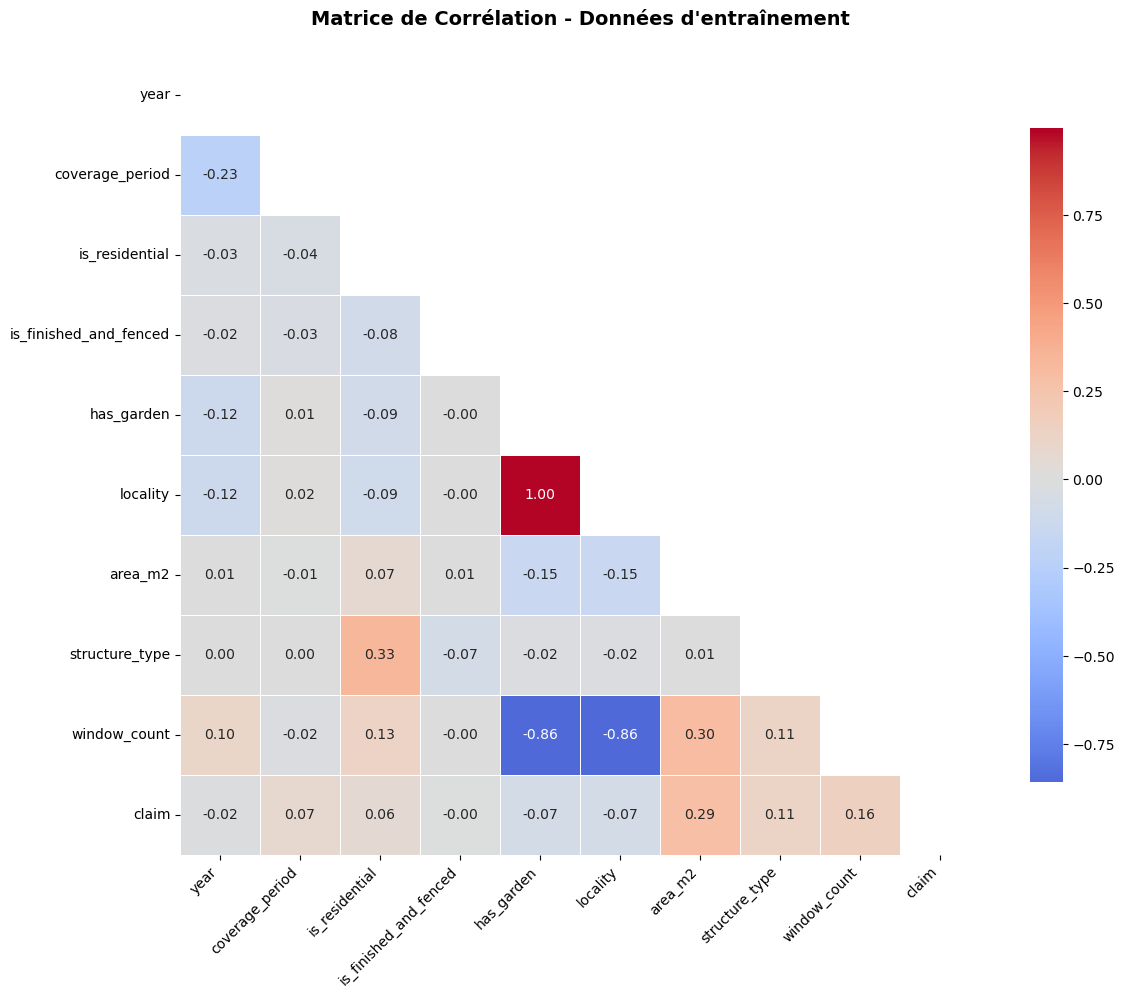

📊 CORRÉLATIONS FORTES (|r| > 0.7):
  has_garden ↔ locality: 0.998
  locality ↔ window_count: -0.859
  has_garden ↔ window_count: -0.858


In [70]:
print("=== MATRICE DE CORRÉLATION AVANCÉE ===")

def display_correlation_matrix(df, title="Matrice de Corrélation"):
    """
    Affiche une matrice de corrélation complète pour toutes les variables
    """
    print(f"=== {title.upper()} ===\n")
    
    # Créer une copie pour l'analyse
    df_corr = df.copy()
    
    # Variables numériques
    numerical_vars = df_corr.select_dtypes(include=[np.number]).columns.tolist()
    
    if len(numerical_vars) < 2:
        print("❌ Pas assez de variables numériques pour la corrélation")
        return None, None
    
    # Calcul de la matrice de corrélation
    correlation_matrix = df_corr[numerical_vars].corr()
    
    # Affichage de la matrice
    plt.figure(figsize=(12, 10))
    
    # Masque pour le triangle supérieur
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    sns.heatmap(correlation_matrix,
                mask=mask,
                annot=True,
                cmap='coolwarm',
                center=0,
                fmt='.2f',
                square=True,
                cbar_kws={'shrink': 0.8},
                linewidths=0.5)
    
    plt.title(f'{title}\n', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Corrélations fortes (> 0.7 ou < -0.7)
    print("📊 CORRÉLATIONS FORTES (|r| > 0.7):")
    strong_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.7:
                strong_corr.append((correlation_matrix.columns[i], 
                                  correlation_matrix.columns[j], 
                                  corr_value))
    
    if strong_corr:
        for var1, var2, corr in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {var1} ↔ {var2}: {corr:.3f}")
    else:
        print("  Aucune corrélation forte détectée")
    
    return df_corr, correlation_matrix

# Application sur les données d'entraînement
df_corr_train, corr_matrix_train = display_correlation_matrix(
    df_train, 
    "Matrice de Corrélation - Données d'entraînement"
)

## 🤖 ÉTAPE 5 : MODÉLISATION

### 5.1 Préparation des données
Séparation features/target et analyse du déséquilibre des classes.

In [72]:
print("=== PRÉPARATION DES DONNÉES POUR LA MODÉLISATION ===")

# Séparation features/target
X_train = df_train.drop(columns=['claim'])
y_train = df_train['claim']

X_test = df_test.drop(columns=['claim'])
y_test = df_test['claim']

print(f"Dimensions X_train: {X_train.shape}")
print(f"Dimensions y_train: {y_train.shape}")
print(f"Dimensions X_test: {X_test.shape}")
print(f"Dimensions y_test: {y_test.shape}")

# Distribution des classes
print("\n📊 DISTRIBUTION DES CLASSES:")
print("Train:")
print(y_train.value_counts())
print(f"Ratio: {y_train.value_counts()[0] / y_train.value_counts()[1]:.2f}:1")

print("\nTest:")
print(y_test.value_counts())
print(f"Ratio: {y_test.value_counts()[0] / y_test.value_counts()[1]:.2f}:1")

=== PRÉPARATION DES DONNÉES POUR LA MODÉLISATION ===
Dimensions X_train: (5012, 9)
Dimensions y_train: (5012,)
Dimensions X_test: (2147, 9)
Dimensions y_test: (2147,)

📊 DISTRIBUTION DES CLASSES:
Train:
claim
0.0    3886
1.0    1126
Name: count, dtype: int64
Ratio: 3.45:1

Test:
claim
0.0    1639
1.0     508
Name: count, dtype: int64
Ratio: 3.23:1


### 5.2 Entraînement RandomForest de base
Modèle de référence avec paramètres par défaut.

=== ENTRAÎNEMENT D'UN RANDOMFOREST DE BASE ===
Entraînement du modèle en cours...

📈 PERFORMANCES DU MODÈLE DE BASE:
Rapport de classification:
              precision    recall  f1-score   support

         0.0       0.80      0.86      0.83      1639
         1.0       0.41      0.31      0.36       508

    accuracy                           0.73      2147
   macro avg       0.61      0.59      0.59      2147
weighted avg       0.71      0.73      0.72      2147

AUC: 0.6584


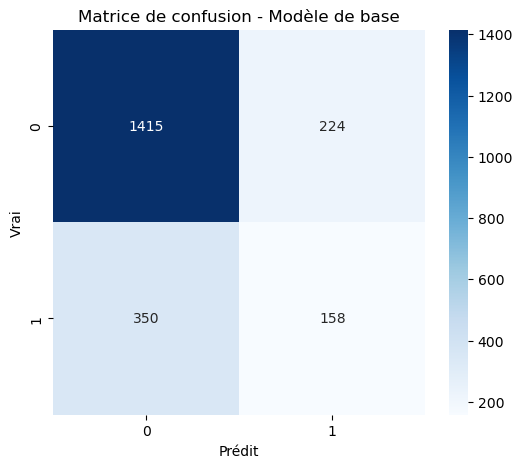

In [74]:
print("=== ENTRAÎNEMENT D'UN RANDOMFOREST DE BASE ===")

# Modèle RandomForest avec paramètres par défaut
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

print("Entraînement du modèle en cours...")
rf_base.fit(X_train, y_train)

# Prédictions
y_pred_base = rf_base.predict(X_test)
y_proba_base = rf_base.predict_proba(X_test)[:, 1]

# Évaluation
print("\n📈 PERFORMANCES DU MODÈLE DE BASE:")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_base))

# Calcul de l'AUC
auc_base = roc_auc_score(y_test, y_proba_base)
print(f"AUC: {auc_base:.4f}")

# Matrice de confusion
cm_base = confusion_matrix(y_test, y_pred_base)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Modèle de base')
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.show()

### 5.3 Optimisation des hyperparamètres
Recherche des meilleurs paramètres avec GridSearchCV.

In [76]:
print("=== OPTIMISATION DES HYPERPARAMÈTRES (GRIDSEARCH) ===")

# Définition de la grille de paramètres
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Création du modèle
rf = RandomForestClassifier(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Recherche des meilleurs hyperparamètres en cours...")
grid_search.fit(X_train, y_train)

# Affichage des meilleurs paramètres
print("\n🎯 MEILLEURS PARAMÈTRES TROUVÉS:")
print(grid_search.best_params_)
print(f"Meilleur score AUC: {grid_search.best_score_:.4f}")

# Récupération du meilleur modèle
best_rf = grid_search.best_estimator_

=== OPTIMISATION DES HYPERPARAMÈTRES (GRIDSEARCH) ===
Recherche des meilleurs hyperparamètres en cours...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

🎯 MEILLEURS PARAMÈTRES TROUVÉS:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur score AUC: 0.7065


### 5.4 Évaluation du modèle optimisé
Analyse détaillée des performances.

=== ÉVALUATION DU MODÈLE OPTIMISÉ ===
📈 PERFORMANCES DU MODÈLE OPTIMISÉ:
Rapport de classification:
              precision    recall  f1-score   support

         0.0       0.78      0.98      0.87      1639
         1.0       0.60      0.10      0.17       508

    accuracy                           0.77      2147
   macro avg       0.69      0.54      0.52      2147
weighted avg       0.74      0.77      0.70      2147


📊 MÉTRIQUES DÉTAILLÉES:
AUC: 0.7146
Précision: 0.6049
Recall: 0.0965
F1-score: 0.1664
Accuracy: 0.7713


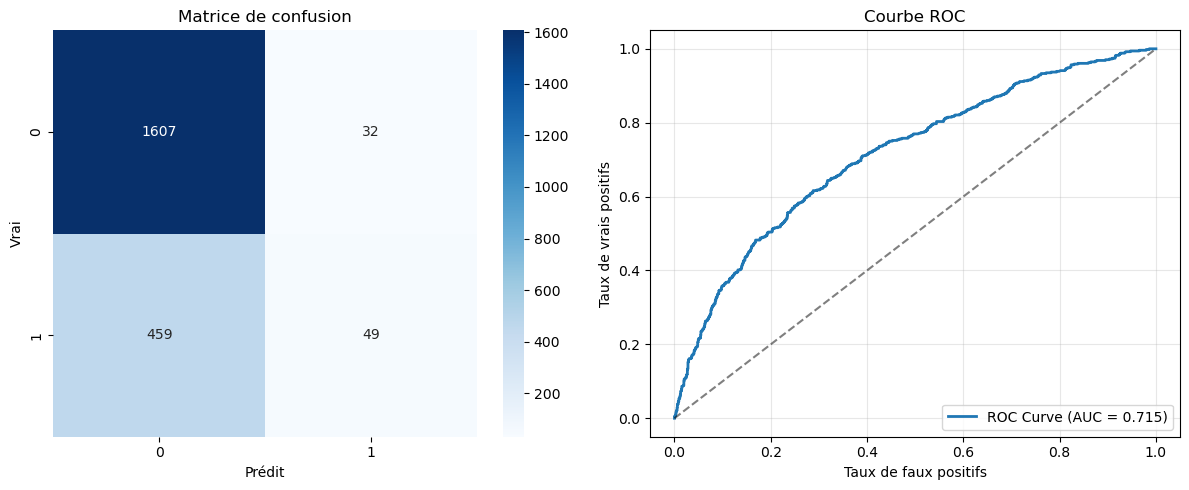

In [78]:
print("=== ÉVALUATION DU MODÈLE OPTIMISÉ ===")

# Prédictions avec le modèle optimisé
y_pred_optimized = best_rf.predict(X_test)
y_proba_optimized = best_rf.predict_proba(X_test)[:, 1]

# Évaluation
print("📈 PERFORMANCES DU MODÈLE OPTIMISÉ:")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_optimized))

# Calcul des métriques
auc_optimized = roc_auc_score(y_test, y_proba_optimized)
precision_opt = precision_score(y_test, y_pred_optimized)
recall_opt = recall_score(y_test, y_pred_optimized)
f1_opt = f1_score(y_test, y_pred_optimized)
accuracy_opt = accuracy_score(y_test, y_pred_optimized)

print(f"\n📊 MÉTRIQUES DÉTAILLÉES:")
print(f"AUC: {auc_optimized:.4f}")
print(f"Précision: {precision_opt:.4f}")
print(f"Recall: {recall_opt:.4f}")
print(f"F1-score: {f1_opt:.4f}")
print(f"Accuracy: {accuracy_opt:.4f}")

# Matrice de confusion
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matrice de confusion')
axes[0].set_ylabel('Vrai')
axes[0].set_xlabel('Prédit')

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_optimized)
axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_optimized:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('Taux de faux positifs')
axes[1].set_ylabel('Taux de vrais positifs')
axes[1].set_title('Courbe ROC')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.5 Importance des features
Identification des variables les plus prédictives.

=== ANALYSE DE L'IMPORTANCE DES FEATURES ===
Toutes les features par ordre d'importance:
               Feature  Importance
               area_m2    0.616976
          window_count    0.172088
        structure_type    0.097301
       coverage_period    0.038767
                  year    0.030459
        is_residential    0.017095
is_finished_and_fenced    0.010589
            has_garden    0.009038
              locality    0.007686


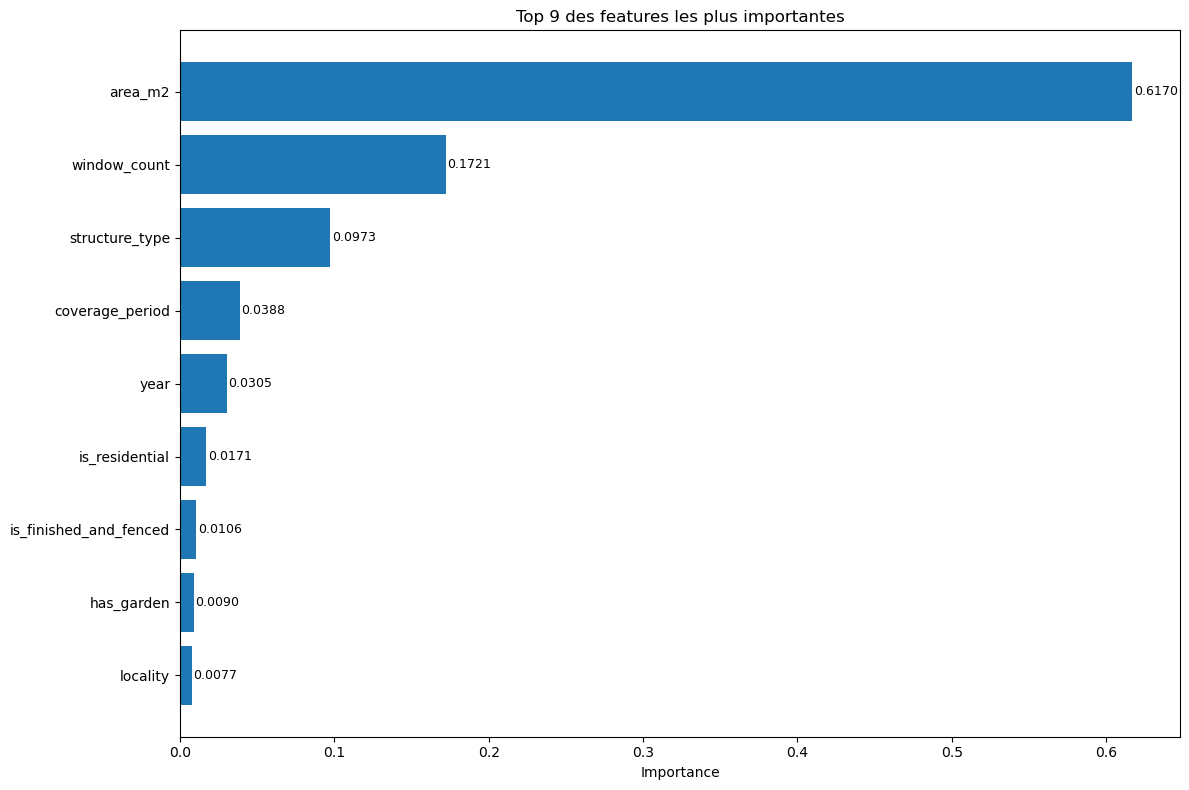


🎯 TOP 5 FEATURES SÉLECTIONNÉES:
  1. area_m2
  2. window_count
  3. structure_type
  4. coverage_period
  5. year


In [81]:
print("=== ANALYSE DE L'IMPORTANCE DES FEATURES ===")

# Extraction des importances
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

# Création d'un DataFrame pour l'analyse
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Toutes les features par ordre d'importance:")
print(feature_importance_df.to_string(index=False))

# Déterminer le nombre réel de features
n_features = len(feature_importance_df)
n_show = min(10, n_features)  # Afficher au maximum 10 features

# Visualisation
plt.figure(figsize=(12, 8))
bars = plt.barh(range(n_show), feature_importance_df.head(n_show)['Importance'][::-1])
plt.yticks(range(n_show), feature_importance_df.head(n_show)['Feature'][::-1])
plt.xlabel('Importance')
plt.title(f'Top {n_show} des features les plus importantes')
plt.tight_layout()

# Ajout des valeurs sur les barres
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f'{width:.4f}', ha='left', va='center', fontsize=9)

plt.show()

# Identification des 5 features les plus importantes
top_5_features = feature_importance_df.head(5)['Feature'].tolist()
print(f"\n🎯 TOP 5 FEATURES SÉLECTIONNÉES:")
for i, feature in enumerate(top_5_features, 1):
    print(f"  {i}. {feature}")

### 5.6 Modèle avec 5 features principales
Simplification du modèle avec les variables les plus importantes.

In [83]:
print("=== MODÈLE AVEC LES 5 FEATURES LES PLUS IMPORTANTES ===")

# Sélection des features
X_train_top5 = X_train[top_5_features]
X_test_top5 = X_test[top_5_features]

print(f"Dimensions X_train_top5: {X_train_top5.shape}")
print(f"Dimensions X_test_top5: {X_test_top5.shape}")
print(f"Features utilisées: {top_5_features}")

# Entraînement du modèle
rf_top5 = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=42
)

rf_top5.fit(X_train_top5, y_train)

# Prédictions
y_pred_top5 = rf_top5.predict(X_test_top5)
y_proba_top5 = rf_top5.predict_proba(X_test_top5)[:, 1]

# Évaluation
print("\n📈 PERFORMANCES AVEC 5 FEATURES:")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_top5))

auc_top5 = roc_auc_score(y_test, y_proba_top5)
print(f"AUC avec 5 features: {auc_top5:.4f}")

# Comparaison avec le modèle complet
print(f"\n📊 COMPARAISON:")
print(f"AUC modèle complet: {auc_optimized:.4f}")
print(f"AUC avec 5 features: {auc_top5:.4f}")
print(f"Différence: {auc_top5 - auc_optimized:+.4f}")

=== MODÈLE AVEC LES 5 FEATURES LES PLUS IMPORTANTES ===
Dimensions X_train_top5: (5012, 5)
Dimensions X_test_top5: (2147, 5)
Features utilisées: ['area_m2', 'window_count', 'structure_type', 'coverage_period', 'year']

📈 PERFORMANCES AVEC 5 FEATURES:
Rapport de classification:
              precision    recall  f1-score   support

         0.0       0.78      0.98      0.87      1639
         1.0       0.63      0.12      0.20       508

    accuracy                           0.78      2147
   macro avg       0.70      0.55      0.54      2147
weighted avg       0.75      0.78      0.71      2147

AUC avec 5 features: 0.7146

📊 COMPARAISON:
AUC modèle complet: 0.7146
AUC avec 5 features: 0.7146
Différence: -0.0001


### 5.7 Rééquilibrage avec SMOTE
Traitement du déséquilibre des classes.

In [85]:
print("=== RÉÉQUILIBRAGE DES CLASSES AVEC SMOTE ===")

# Application de SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Distribution des classes avant SMOTE:")
print(y_train.value_counts())
print(f"Ratio: {y_train.value_counts()[0] / y_train.value_counts()[1]:.2f}:1")

print("\nDistribution des classes après SMOTE:")
print(y_train_smote.value_counts())
print(f"Ratio: {y_train_smote.value_counts()[0] / y_train_smote.value_counts()[1]:.2f}:1")

# Entraînement du modèle avec données rééquilibrées
rf_smote = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

# Prédictions
y_pred_smote = rf_smote.predict(X_test)
y_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

# Évaluation
print("\n📈 PERFORMANCES AVEC SMOTE:")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_smote))

auc_smote = roc_auc_score(y_test, y_proba_smote)
print(f"AUC avec SMOTE: {auc_smote:.4f}")

# Comparaison
print(f"\n📊 COMPARAISON AVEC LE MODÈLE SANS RÉÉQUILIBRAGE:")
print(f"AUC sans rééquilibrage: {auc_optimized:.4f}")
print(f"AUC avec SMOTE: {auc_smote:.4f}")
print(f"Différence: {auc_smote - auc_optimized:+.4f}")

=== RÉÉQUILIBRAGE DES CLASSES AVEC SMOTE ===
Distribution des classes avant SMOTE:
claim
0.0    3886
1.0    1126
Name: count, dtype: int64
Ratio: 3.45:1

Distribution des classes après SMOTE:
claim
0.0    3886
1.0    3886
Name: count, dtype: int64
Ratio: 1.00:1

📈 PERFORMANCES AVEC SMOTE:
Rapport de classification:
              precision    recall  f1-score   support

         0.0       0.85      0.72      0.78      1639
         1.0       0.40      0.59      0.48       508

    accuracy                           0.69      2147
   macro avg       0.62      0.66      0.63      2147
weighted avg       0.74      0.69      0.71      2147

AUC avec SMOTE: 0.7043

📊 COMPARAISON AVEC LE MODÈLE SANS RÉÉQUILIBRAGE:
AUC sans rééquilibrage: 0.7146
AUC avec SMOTE: 0.7043
Différence: -0.0103


### 5.8 Ajustement du seuil de décision
Optimisation du seuil pour améliorer les métriques.

=== AJUSTEMENT DU SEUIL DE DÉCISION ===
Recherche du meilleur seuil de décision...
Seuil 0.3: Precision=0.275, Recall=0.898, F1=0.421
Seuil 0.35: Precision=0.298, Recall=0.833, F1=0.439
Seuil 0.4: Precision=0.312, Recall=0.772, F1=0.444
Seuil 0.45: Precision=0.335, Recall=0.720, F1=0.458
Seuil 0.5: Precision=0.398, Recall=0.591, F1=0.475

📊 RÉSULTATS PAR SEUIL:
 Threshold  Precision   Recall  F1-score
      0.30   0.274864 0.897638  0.420858
      0.35   0.298307 0.832677  0.439252
      0.40   0.311854 0.771654  0.444193
      0.45   0.335165 0.720472  0.457500
      0.50   0.397878 0.590551  0.475436

🎯 MEILLEUR SEUIL: 0.50 (F1-score max)

📈 PERFORMANCES AVEC LE MEILLEUR SEUIL:
Rapport de classification:
              precision    recall  f1-score   support

         0.0       0.85      0.72      0.78      1639
         1.0       0.40      0.59      0.48       508

    accuracy                           0.69      2147
   macro avg       0.62      0.66      0.63      2147
weighted avg

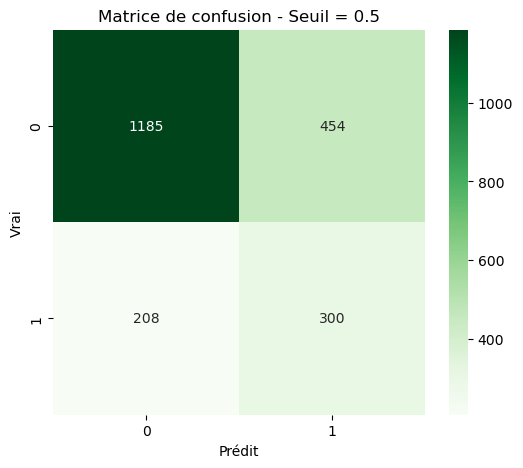

In [87]:
print("=== AJUSTEMENT DU SEUIL DE DÉCISION ===")

# Utilisation des probabilités du modèle SMOTE
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
results = []

print("Recherche du meilleur seuil de décision...")
for threshold in thresholds:
    y_pred_threshold = (y_proba_smote > threshold).astype(int)
    
    # Calcul des métriques
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })
    
    print(f"Seuil {threshold}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")

# Affichage des résultats
results_df = pd.DataFrame(results)
print("\n📊 RÉSULTATS PAR SEUIL:")
print(results_df.to_string(index=False))

# Recherche du meilleur seuil (max F1-score)
best_threshold = results_df.loc[results_df['F1-score'].idxmax(), 'Threshold']
print(f"\n🎯 MEILLEUR SEUIL: {best_threshold:.2f} (F1-score max)")

# Application du meilleur seuil
y_pred_best_threshold = (y_proba_smote > best_threshold).astype(int)

print("\n📈 PERFORMANCES AVEC LE MEILLEUR SEUIL:")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_best_threshold))

# Matrice de confusion
cm_threshold = confusion_matrix(y_test, y_pred_best_threshold)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_threshold, annot=True, fmt='d', cmap='Greens')
plt.title(f'Matrice de confusion - Seuil = {best_threshold}')
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.show()

### 5.9 Calibration du modèle
Amélioration de la fiabilité des probabilités prédites.

=== CALIBRATION DU MODÈLE ===
Calibration du modèle en cours...

📈 PERFORMANCES APRÈS CALIBRATION:
Rapport de classification:
              precision    recall  f1-score   support

         0.0       0.79      0.97      0.87      1639
         1.0       0.62      0.16      0.25       508

    accuracy                           0.78      2147
   macro avg       0.70      0.56      0.56      2147
weighted avg       0.75      0.78      0.72      2147

AUC après calibration: 0.7158

📊 COMPARAISON:
AUC avant calibration: 0.7146
AUC après calibration: 0.7158
Différence: +0.0011


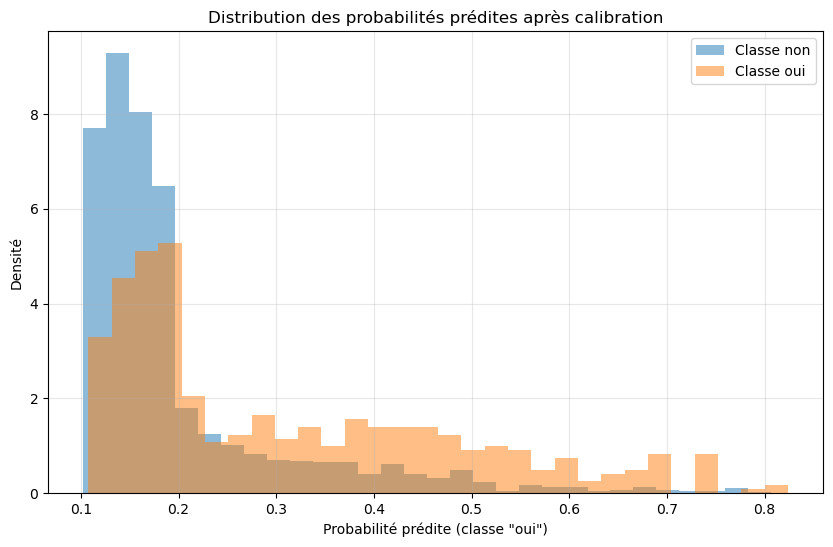

In [89]:
print("=== CALIBRATION DU MODÈLE ===")

# Calibration avec sigmoid
calibrated_rf = CalibratedClassifierCV(
    best_rf,
    method='sigmoid',
    cv=5
)

print("Calibration du modèle en cours...")
calibrated_rf.fit(X_train, y_train)

# Prédictions calibrées
y_proba_calibrated = calibrated_rf.predict_proba(X_test)[:, 1]
y_pred_calibrated = (y_proba_calibrated > 0.5).astype(int)

# Évaluation
print("\n📈 PERFORMANCES APRÈS CALIBRATION:")
print("Rapport de classification:")
print(classification_report(y_test, y_pred_calibrated))

auc_calibrated = roc_auc_score(y_test, y_proba_calibrated)
print(f"AUC après calibration: {auc_calibrated:.4f}")

# Comparaison
print(f"\n📊 COMPARAISON:")
print(f"AUC avant calibration: {auc_optimized:.4f}")
print(f"AUC après calibration: {auc_calibrated:.4f}")
print(f"Différence: {auc_calibrated - auc_optimized:+.4f}")

# Visualisation de la calibration
plt.figure(figsize=(10, 6))

# Distribution des probabilités
for label in [0, 1]:
    mask = y_test == label
    plt.hist(y_proba_calibrated[mask], bins=30, alpha=0.5,
             label=f'Classe {"non" if label == 0 else "oui"}',
             density=True)

plt.xlabel('Probabilité prédite (classe "oui")')
plt.ylabel('Densité')
plt.title('Distribution des probabilités prédites après calibration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.10 Synthèse des performances
Comparaison finale de tous les modèles et recommandations.

In [91]:
print("=== SYNTHÈSE DES PERFORMANCES ===")

# Création d'un tableau comparatif
comparison_data = {
    'Modèle': ['RandomForest de base', 'RandomForest optimisé', 
               '5 features seulement', 'Avec SMOTE', 
               f'SMOTE + seuil {best_threshold}', 'Avec calibration'],
    'AUC': [auc_base, auc_optimized, auc_top5, auc_smote, 
            roc_auc_score(y_test, (y_proba_smote > best_threshold).astype(int)), 
            auc_calibrated],
    'Précision': [precision_score(y_test, y_pred_base),
                 precision_score(y_test, y_pred_optimized),
                 precision_score(y_test, y_pred_top5),
                 precision_score(y_test, y_pred_smote),
                 precision_score(y_test, y_pred_best_threshold),
                 precision_score(y_test, y_pred_calibrated)],
    'Recall': [recall_score(y_test, y_pred_base),
              recall_score(y_test, y_pred_optimized),
              recall_score(y_test, y_pred_top5),
              recall_score(y_test, y_pred_smote),
              recall_score(y_test, y_pred_best_threshold),
              recall_score(y_test, y_pred_calibrated)],
    'F1-score': [f1_score(y_test, y_pred_base),
                f1_score(y_test, y_pred_optimized),
                f1_score(y_test, y_pred_top5),
                f1_score(y_test, y_pred_smote),
                f1_score(y_test, y_pred_best_threshold),
                f1_score(y_test, y_pred_calibrated)]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n📊 TABLEAU COMPARATIF:")
print(comparison_df.to_string(index=False))

# Recommandations
print("\n🎯 RECOMMANDATIONS FINALES:")
print("1. Pour maximiser l'AUC: Utiliser le modèle RandomForest optimisé")
print("2. Pour améliorer le recall (détection des 'oui'): Utiliser SMOTE + ajustement du seuil")
print("3. Pour la simplicité: Utiliser le modèle avec 5 features seulement")
print("4. Pour la calibration des probabilités: Utiliser le modèle calibré")

print("\n✅ ANALYSE TERMINÉE AVEC SUCCÈS!")

=== SYNTHÈSE DES PERFORMANCES ===

📊 TABLEAU COMPARATIF:
               Modèle      AUC  Précision   Recall  F1-score
 RandomForest de base 0.658434   0.413613 0.311024  0.355056
RandomForest optimisé 0.714616   0.604938 0.096457  0.166384
 5 features seulement 0.714557   0.626263 0.122047  0.204283
           Avec SMOTE 0.704276   0.397878 0.590551  0.475436
    SMOTE + seuil 0.5 0.656777   0.397878 0.590551  0.475436
     Avec calibration 0.715754   0.615385 0.157480  0.250784

🎯 RECOMMANDATIONS FINALES:
1. Pour maximiser l'AUC: Utiliser le modèle RandomForest optimisé
2. Pour améliorer le recall (détection des 'oui'): Utiliser SMOTE + ajustement du seuil
3. Pour la simplicité: Utiliser le modèle avec 5 features seulement
4. Pour la calibration des probabilités: Utiliser le modèle calibré

✅ ANALYSE TERMINÉE AVEC SUCCÈS!


### Gradient Boosting avec SMOTETomek
Amélioration du modèle avec rééquilibrage SMOTETomek et algorithme Gradient Boosting optimisé.

In [97]:
from imblearn.combine import SMOTETomek
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_recall_fscore_support,
                             classification_report, confusion_matrix)
import numpy as np

# Données
X_train = df_train.drop("claim", axis=1)
y_train = df_train["claim"]
X_test  = df_test.drop("claim", axis=1)
y_test  = df_test["claim"]

# SMOTETomek - Combinaison de sur-échantillonnage et sous-échantillonnage
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)

print("=== DISTRIBUTION DES CLASSES ===")
print("Avant SMOTETomek :")
print(y_train.value_counts())
print(f"Ratio : {y_train.value_counts()[0] / y_train.value_counts()[1]:.2f}:1")

print("\nAprès SMOTETomek :")
print(y_train_st.value_counts())
print(f"Ratio : {y_train_st.value_counts()[0] / y_train_st.value_counts()[1]:.2f}:1")

# Gradient Boosting avec paramètres optimisés
gbc = GradientBoostingClassifier(
    n_estimators=400,     # Plus d'arbres pour une meilleure stabilité
    learning_rate=0.03,   # Pas d'apprentissage petit pour éviter le surapprentissage
    max_depth=3,          # Arbres peu profonds pour la régularisation
    subsample=0.9,        # Utilisation de 90% des données pour chaque arbre
    max_features='sqrt',  # Nombre de features à considérer
    random_state=42
)

print("\n=== ENTRAÎNEMENT DU GRADIENT BOOSTING ===")
gbc.fit(X_train_st, y_train_st)
print("✅ Modèle entraîné avec succès!")

=== DISTRIBUTION DES CLASSES ===
Avant SMOTETomek :
claim
0.0    3886
1.0    1126
Name: count, dtype: int64
Ratio : 3.45:1

Après SMOTETomek :
claim
0.0    3433
1.0    3433
Name: count, dtype: int64
Ratio : 1.00:1

=== ENTRAÎNEMENT DU GRADIENT BOOSTING ===
✅ Modèle entraîné avec succès!


### Recherche du seuil optimal
Recherche systématique du meilleur seuil pour maximiser le F1-score de la classe minoritaire.

=== RECHERCHE DU MEILLEUR SEUIL DE DÉCISION ===
Seuil | Accuracy | Precision (1) | Recall (1) | F1-score (1)
------------------------------------------------------------
0.25 | 0.4932 | 0.3014 | 0.8661 | 0.4472
0.27 | 0.5072 | 0.3044 | 0.8425 | 0.4472
0.29 | 0.5212 | 0.3083 | 0.8228 | 0.4485
0.31 | 0.5347 | 0.3122 | 0.8031 | 0.4496
0.33 | 0.5575 | 0.3218 | 0.7854 | 0.4565
0.35 | 0.5748 | 0.3277 | 0.7579 | 0.4575
0.37 | 0.5915 | 0.3351 | 0.7382 | 0.4610
0.39 | 0.6153 | 0.3483 | 0.7185 | 0.4692
0.41 | 0.6376 | 0.3605 | 0.6870 | 0.4729
0.43 | 0.6581 | 0.3739 | 0.6594 | 0.4772
0.45 | 0.6768 | 0.3855 | 0.6161 | 0.4742
0.47 | 0.6986 | 0.4049 | 0.5827 | 0.4778
0.49 | 0.7177 | 0.4248 | 0.5453 | 0.4776

🎯 MEILLEUR SEUIL TROUVÉ : 0.47
F1-score (classe 1) : 0.4778
Accuracy : 0.6986
Précision (classe 1) : 0.4049
Recall (classe 1) : 0.5827

=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

         0.0       0.85      0.73      0.79      1639
         1.0     

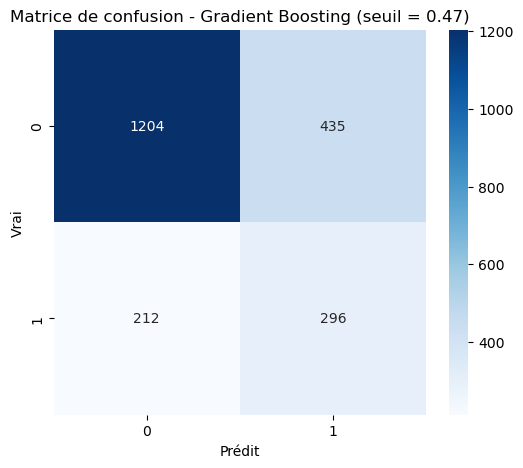

In [100]:
y_proba = gbc.predict_proba(X_test)[:, 1]

# Recherche de seuil pour maximiser F1 de la classe 1
best_thr = None
best_f1_1 = -1
best_acc = 0
best_precision = 0
best_recall = 0

results = []

print("=== RECHERCHE DU MEILLEUR SEUIL DE DÉCISION ===")
print("Seuil | Accuracy | Precision (1) | Recall (1) | F1-score (1)")
print("-" * 60)

for thr in np.arange(0.25, 0.51, 0.02):
    y_pred_thr = (y_proba >= thr).astype(int)
    acc = accuracy_score(y_test, y_pred_thr)
    prec, rec, f1s, supp = precision_recall_fscore_support(
        y_test, y_pred_thr, labels=[0, 1], zero_division=0
    )
    f1_1 = f1s[1]
    precision_1 = prec[1]
    recall_1 = rec[1]
    
    results.append({
        'threshold': thr,
        'accuracy': acc,
        'precision_1': precision_1,
        'recall_1': recall_1,
        'f1_1': f1_1
    })
    
    print(f"{thr:.2f} | {acc:.4f} | {precision_1:.4f} | {recall_1:.4f} | {f1_1:.4f}")
    
    if f1_1 > best_f1_1:
        best_f1_1 = f1_1
        best_thr = thr
        best_acc = acc
        best_precision = precision_1
        best_recall = recall_1

print("\n" + "="*60)
print(f"🎯 MEILLEUR SEUIL TROUVÉ : {best_thr:.2f}")
print(f"F1-score (classe 1) : {best_f1_1:.4f}")
print(f"Accuracy : {best_acc:.4f}")
print(f"Précision (classe 1) : {best_precision:.4f}")
print(f"Recall (classe 1) : {best_recall:.4f}")

# Application du meilleur seuil
y_pred = (y_proba >= best_thr).astype(int)

print("\n=== RAPPORT DE CLASSIFICATION ===")
print(classification_report(y_test, y_pred))

print("=== MATRICE DE CONFUSION ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualisation de la matrice de confusion
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matrice de confusion - Gradient Boosting (seuil = {best_thr:.2f})')
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.show()

### Courbe ROC
Visualisation de la performance du modèle avec la courbe ROC et calcul de l'AUC.

=== COURBE ROC - GRADIENT BOOSTING ===
AUC = 0.7112


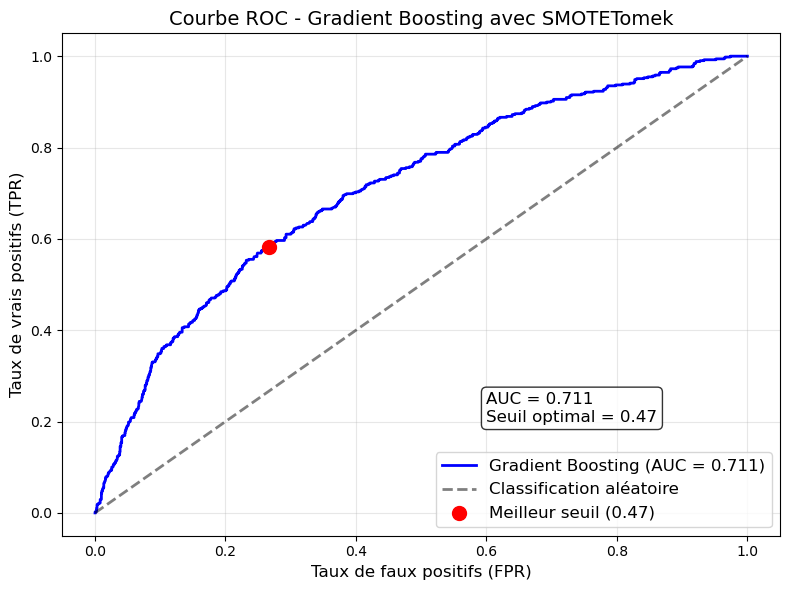

In [103]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calcul des métriques ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Affichage
print(f"=== COURBE ROC - GRADIENT BOOSTING ===")
print(f"AUC = {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Gradient Boosting (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Classification aléatoire')

# Marquer le meilleur seuil trouvé
best_thr_idx = np.argmin(np.abs(thresholds - best_thr))
plt.scatter(fpr[best_thr_idx], tpr[best_thr_idx], 
            color='red', s=100, zorder=5, 
            label=f'Meilleur seuil ({best_thr:.2f})')

plt.xlabel('Taux de faux positifs (FPR)', fontsize=12)
plt.ylabel('Taux de vrais positifs (TPR)', fontsize=12)
plt.title('Courbe ROC - Gradient Boosting avec SMOTETomek', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)

# Ajouter des informations supplémentaires
plt.text(0.6, 0.2, f'AUC = {roc_auc:.3f}\nSeuil optimal = {best_thr:.2f}', 
         fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

### Importance des features
Analyse des variables les plus influentes dans les prédictions du modèle.

=== IMPORTANCE DES FEATURES - GRADIENT BOOSTING ===
               Feature  Importance
               area_m2    0.374681
       coverage_period    0.285817
        structure_type    0.128159
          window_count    0.072254
        is_residential    0.063863
                  year    0.057316
is_finished_and_fenced    0.010648
            has_garden    0.004725
              locality    0.002537


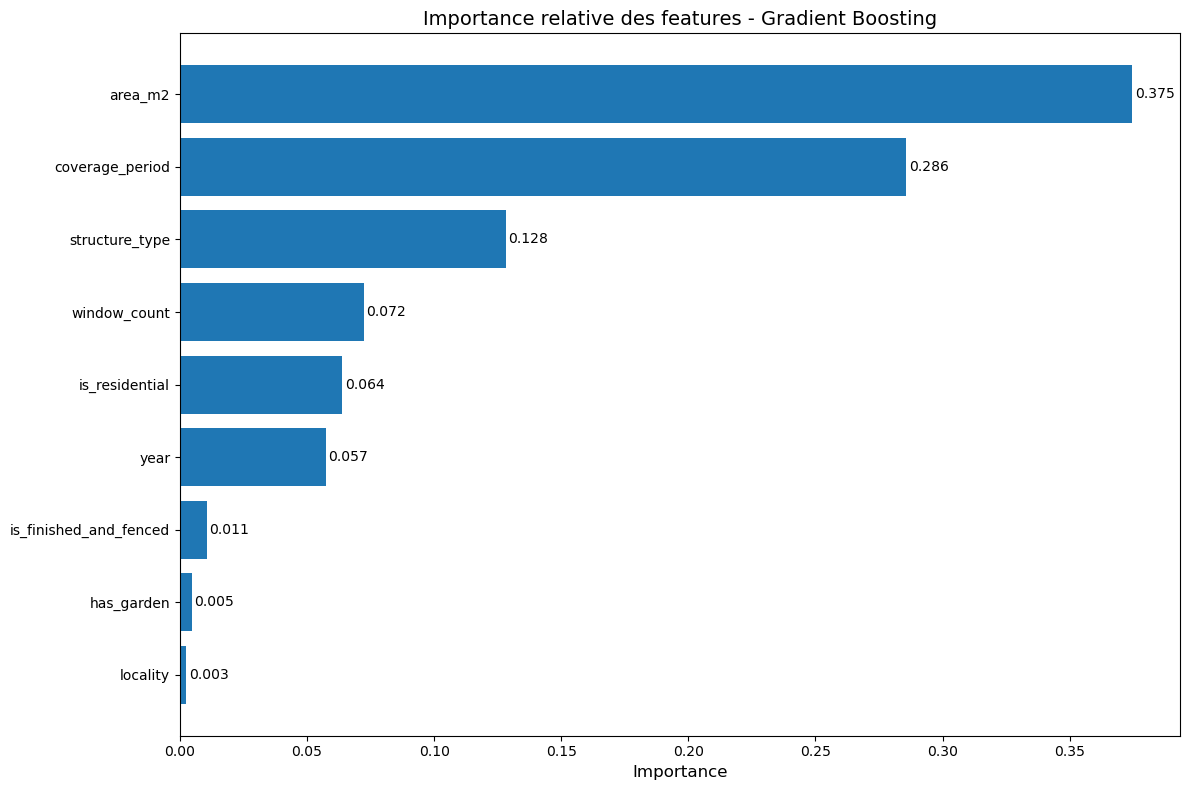


📊 INSIGHTS SUR L'IMPORTANCE DES FEATURES :

Top 3 des features les plus importantes :
  area_m2: 0.375 (37.5%)
  coverage_period: 0.286 (28.6%)
  structure_type: 0.128 (12.8%)

Répartition de l'importance :
  Top 3 features: 78.9% de l'importance totale
  Autres features: 21.1%


In [106]:
import numpy as np

# Extraction des importances
importances = gbc.feature_importances_
features = X_train.columns

# Création d'un DataFrame pour l'analyse
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== IMPORTANCE DES FEATURES - GRADIENT BOOSTING ===")
print(importance_df.to_string(index=False))

# Visualisation
plt.figure(figsize=(12, 8))

# Barres horizontales pour meilleure lisibilité
bars = plt.barh(range(len(importance_df)), importance_df['Importance'][::-1])
plt.yticks(range(len(importance_df)), importance_df['Feature'][::-1])
plt.xlabel('Importance', fontsize=12)
plt.title('Importance relative des features - Gradient Boosting', fontsize=14)

# Ajout des valeurs sur les barres
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Analyse des insights
print("\n📊 INSIGHTS SUR L'IMPORTANCE DES FEATURES :")
print("="*50)

top_features = importance_df.head(3)
print("\nTop 3 des features les plus importantes :")
for idx, row in top_features.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.3f} ({row['Importance']*100:.1f}%)")

print("\nRépartition de l'importance :")
print(f"  Top 3 features: {top_features['Importance'].sum()*100:.1f}% de l'importance totale")
print(f"  Autres features: {(1 - top_features['Importance'].sum())*100:.1f}%")

### Visualisation d'un arbre
Examen d'un arbre individuel pour comprendre le fonctionnement interne du modèle.

=== VISUALISATION D'UN ARBRE DU GRADIENT BOOSTING ===
Arbre n°1 (sur 400) - Pour la classe 0


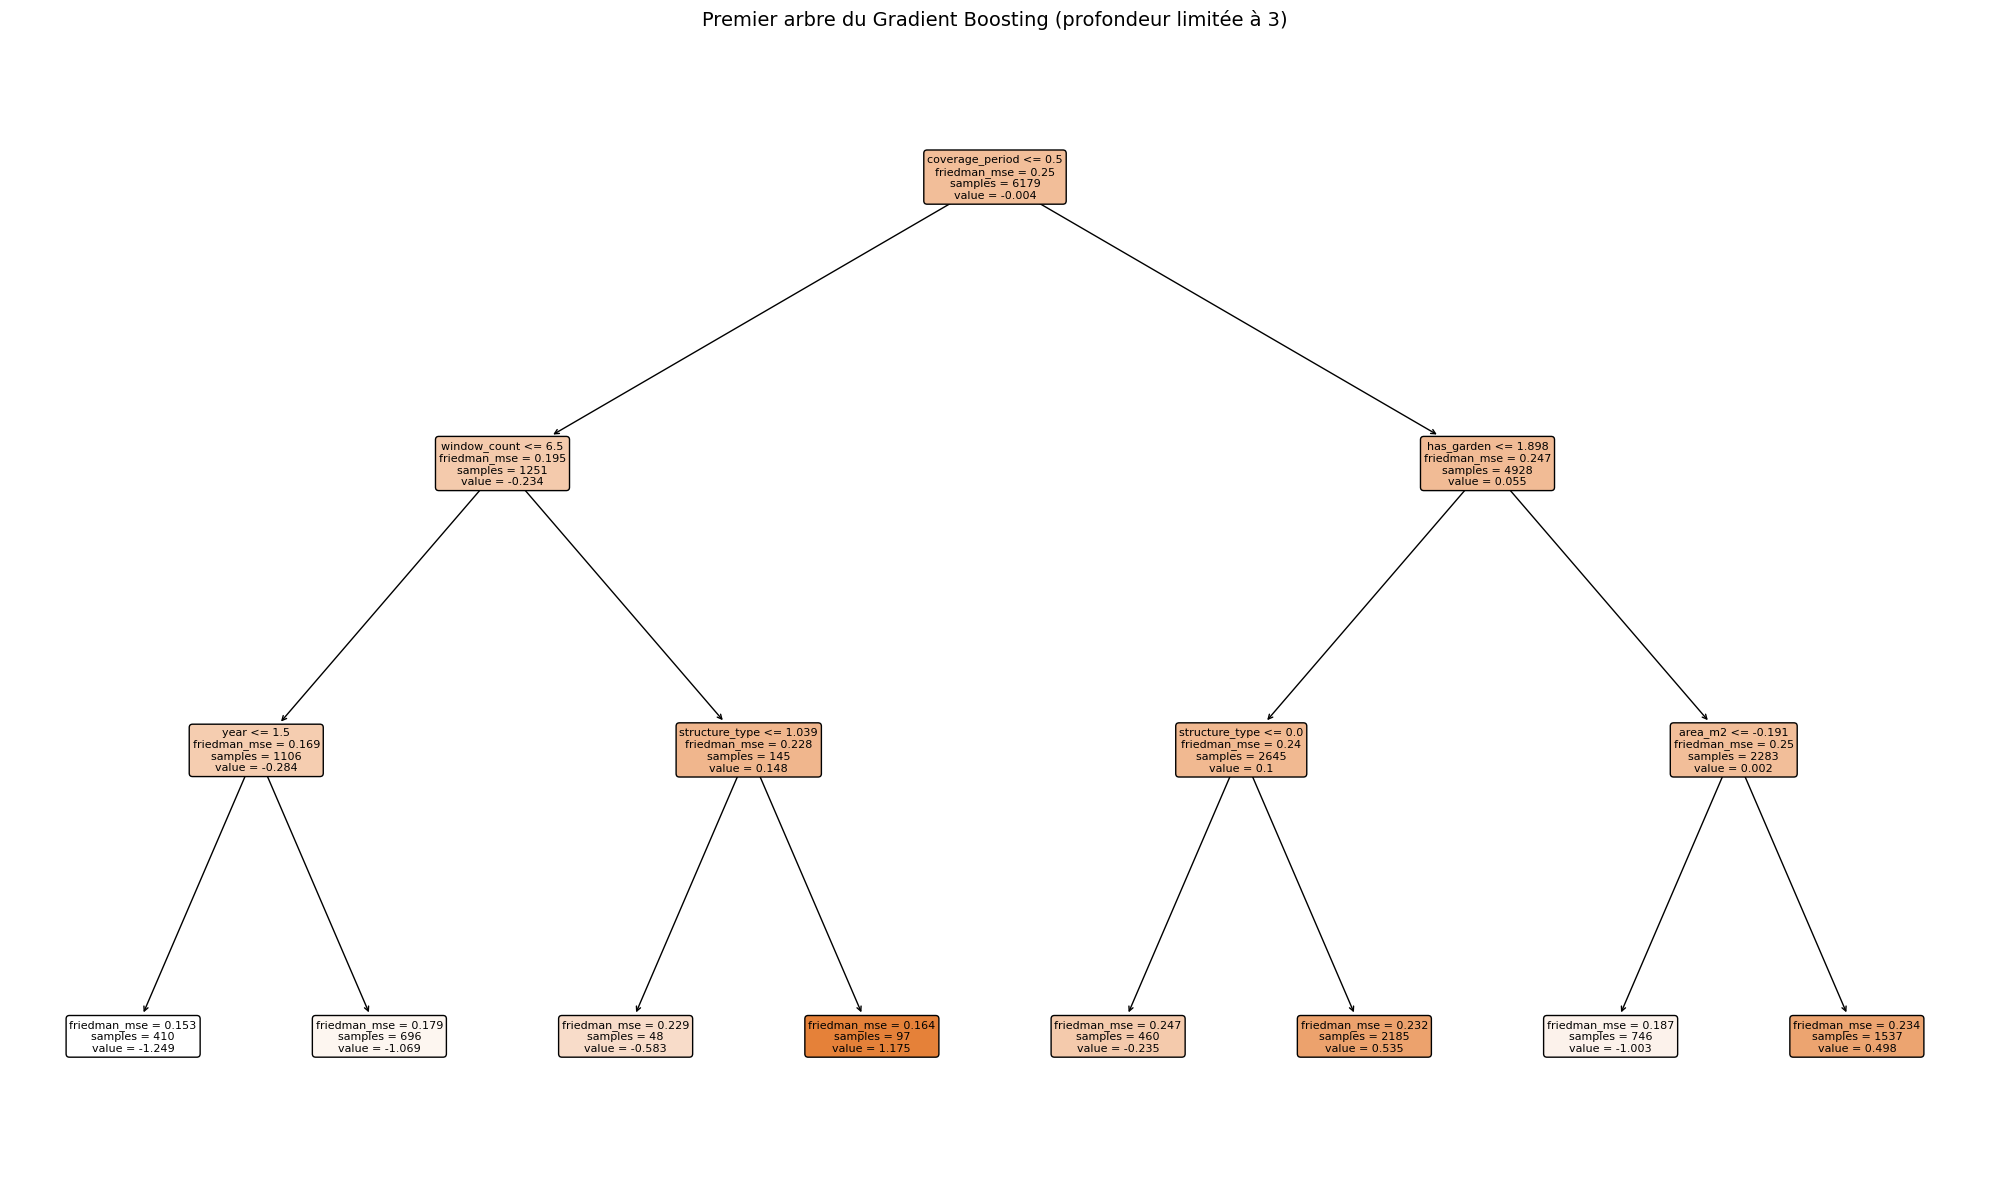


📋 INFORMATIONS SUR L'ARBRE VISUALISÉ :
  • Profondeur maximale : 3
  • Nombre total de nœuds : 15
  • Nombre de feuilles : 8
  • Caractéristiques utilisées : 9

💡 INTERPRÉTATION :
  • Chaque nœud montre la condition de division (ex: area_m2 ≤ 0.5)
  • Les feuilles montrent la valeur prédite (log-odds)
  • Les couleurs indiquent la classe majoritaire dans le nœud
  • Cette visualisation aide à comprendre comment le modèle prend ses décisions


In [109]:
from sklearn.tree import plot_tree

# Visualisation d'un arbre du Gradient Boosting (le premier arbre)
print("=== VISUALISATION D'UN ARBRE DU GRADIENT BOOSTING ===")
print("Arbre n°1 (sur 400) - Pour la classe 0")
print("="*50)

# Récupération du premier arbre (premier estimateur, classe 0)
tree_0 = gbc.estimators_[0, 0]

plt.figure(figsize=(20, 12))
plot_tree(
    tree_0,
    feature_names=X_train.columns,   # Noms des features
    class_names=["no_claim", "claim"],  # Noms des classes
    filled=True,                     # Couleurs selon la classe majoritaire
    rounded=True,                    # Coins arrondis pour une meilleure lisibilité
    fontsize=8,                      # Taille de police
    max_depth=3                      # Limite la profondeur pour la lisibilité
)

plt.title("Premier arbre du Gradient Boosting (profondeur limitée à 3)", fontsize=14)
plt.tight_layout()
plt.show()

# Informations complémentaires sur l'arbre
print("\n📋 INFORMATIONS SUR L'ARBRE VISUALISÉ :")
print(f"  • Profondeur maximale : {tree_0.tree_.max_depth}")
print(f"  • Nombre total de nœuds : {tree_0.tree_.node_count}")
print(f"  • Nombre de feuilles : {tree_0.tree_.n_leaves}")
print(f"  • Caractéristiques utilisées : {tree_0.tree_.n_features}")

print("\n💡 INTERPRÉTATION :")
print("  • Chaque nœud montre la condition de division (ex: area_m2 ≤ 0.5)")
print("  • Les feuilles montrent la valeur prédite (log-odds)")
print("  • Les couleurs indiquent la classe majoritaire dans le nœud")
print("  • Cette visualisation aide à comprendre comment le modèle prend ses décisions")

### Synthèse finale - Comparaison des modèles

**Tableau comparatif des performances :**

In [121]:
print("=== SYNTHÈSE FINALE - COMPARAISON DÉTAILLÉE ===")
print("="*70)

# Création du tableau de comparaison
comparison_data = []

# Fonction pour extraire les métriques
def get_model_metrics(model_name, y_true, y_pred, y_proba=None):
    """Calcule toutes les métriques pour un modèle"""
    from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                                 recall_score, roc_auc_score, confusion_matrix)
    
    metrics = {
        'Modèle': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (classe 1)': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall (classe 1)': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'F1-score (classe 1)': f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    }
    
    if y_proba is not None:
        metrics['AUC'] = roc_auc_score(y_true, y_proba)
    
    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    metrics['TN'] = TN
    metrics['FP'] = FP
    metrics['FN'] = FN
    metrics['TP'] = TP
    metrics['Spécificité'] = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return metrics

# 1. Gradient Boosting avec SMOTETomek (modèle actuel)
print("\n📊 GRADIENT BOOSTING + SMOTETOMEK :")
print(f"   • Meilleur seuil trouvé : {best_thr:.2f}")
gb_metrics = get_model_metrics("Gradient Boosting", y_test, y_pred, y_proba)
comparison_data.append(gb_metrics)

# Affichage détaillé pour Gradient Boosting
print(f"   • AUC : {gb_metrics.get('AUC', 'N/A'):.4f}")
print(f"   • F1-score (classe 1) : {gb_metrics['F1-score (classe 1)']:.4f}")
print(f"   • Précision (classe 1) : {gb_metrics['Precision (classe 1)']:.4f}")
print(f"   • Recall (classe 1) : {gb_metrics['Recall (classe 1)']:.4f}")
print(f"   • Accuracy : {gb_metrics['Accuracy']:.4f}")
print(f"   • Matrice de confusion : TN={gb_metrics['TN']}, FP={gb_metrics['FP']}, FN={gb_metrics['FN']}, TP={gb_metrics['TP']}")

# 2. Random Forest (si disponible)
try:
    # Random Forest optimisé
    print("\n📊 RANDOM FOREST OPTIMISÉ :")
    rf_metrics = get_model_metrics("Random Forest Optimisé", y_test, y_pred_optimized, y_proba_optimized)
    comparison_data.append(rf_metrics)
    
    print(f"   • AUC : {rf_metrics.get('AUC', 'N/A'):.4f}")
    print(f"   • F1-score (classe 1) : {rf_metrics['F1-score (classe 1)']:.4f}")
    print(f"   • Précision (classe 1) : {rf_metrics['Precision (classe 1)']:.4f}")
    print(f"   • Recall (classe 1) : {rf_metrics['Recall (classe 1)']:.4f}")
    print(f"   • Accuracy : {rf_metrics['Accuracy']:.4f}")
    print(f"   • Matrice de confusion : TN={rf_metrics['TN']}, FP={rf_metrics['FP']}, FN={rf_metrics['FN']}, TP={rf_metrics['TP']}")
    
except NameError:
    print("   ⚠️  Métriques Random Forest non disponibles")
    # Créer une entrée vide pour Random Forest
    comparison_data.append({
        'Modèle': 'Random Forest Optimisé',
        'Accuracy': 'N/A',
        'Precision (classe 1)': 'N/A',
        'Recall (classe 1)': 'N/A',
        'F1-score (classe 1)': 'N/A',
        'AUC': 'N/A',
        'TN': 'N/A',
        'FP': 'N/A',
        'FN': 'N/A',
        'TP': 'N/A',
        'Spécificité': 'N/A'
    })

# 3. Random Forest de base (si disponible)
try:
    print("\n📊 RANDOM FOREST DE BASE :")
    rf_base_metrics = get_model_metrics("Random Forest Base", y_test, y_pred_base, y_proba_base)
    comparison_data.append(rf_base_metrics)
    
    print(f"   • AUC : {rf_base_metrics.get('AUC', 'N/A'):.4f}")
    print(f"   • F1-score (classe 1) : {rf_base_metrics['F1-score (classe 1)']:.4f}")
    print(f"   • Précision (classe 1) : {rf_base_metrics['Precision (classe 1)']:.4f}")
    print(f"   • Recall (classe 1) : {rf_base_metrics['Recall (classe 1)']:.4f}")
    print(f"   • Accuracy : {rf_base_metrics['Accuracy']:.4f}")
    print(f"   • Matrice de confusion : TN={rf_base_metrics['TN']}, FP={rf_base_metrics['FP']}, FN={rf_base_metrics['FN']}, TP={rf_base_metrics['TP']}")
    
except NameError:
    print("   ⚠️  Métriques Random Forest Base non disponibles")
    comparison_data.append({
        'Modèle': 'Random Forest Base',
        'Accuracy': 'N/A',
        'Precision (classe 1)': 'N/A',
        'Recall (classe 1)': 'N/A',
        'F1-score (classe 1)': 'N/A',
        'AUC': 'N/A',
        'TN': 'N/A',
        'FP': 'N/A',
        'FN': 'N/A',
        'TP': 'N/A',
        'Spécificité': 'N/A'
    })

# Création du DataFrame de comparaison
comparison_df = pd.DataFrame(comparison_data)

# Réorganisation des colonnes
column_order = ['Modèle', 'AUC', 'Accuracy', 'Precision (classe 1)', 
                'Recall (classe 1)', 'F1-score (classe 1)', 
                'Spécificité', 'TN', 'FP', 'FN', 'TP']
comparison_df = comparison_df[column_order]

print("\n" + "="*70)
print("📋 TABLEAU COMPARATIF COMPLET :")
print("="*70)
print(comparison_df.to_string(index=False))

# Analyse comparative
print("\n" + "="*70)
print("📈 ANALYSE COMPARATIVE :")
print("="*70)

if 'AUC' in comparison_df.columns and comparison_df['AUC'].iloc[0] != 'N/A' and comparison_df['AUC'].iloc[1] != 'N/A':
    auc_gb = comparison_df.loc[comparison_df['Modèle'] == 'Gradient Boosting', 'AUC'].values[0]
    auc_rf = comparison_df.loc[comparison_df['Modèle'] == 'Random Forest Optimisé', 'AUC'].values[0]
    
    if auc_gb > auc_rf:
        print(f"✅ Gradient Boosting surpasse Random Forest en AUC de {auc_gb - auc_rf:.4f}")
    elif auc_rf > auc_gb:
        print(f"✅ Random Forest surpasse Gradient Boosting en AUC de {auc_rf - auc_gb:.4f}")
    else:
        print("⚖️  Les deux modèles ont des performances AUC similaires")

if 'F1-score (classe 1)' in comparison_df.columns:
    f1_gb = comparison_df.loc[comparison_df['Modèle'] == 'Gradient Boosting', 'F1-score (classe 1)'].values[0]
    f1_rf = comparison_df.loc[comparison_df['Modèle'] == 'Random Forest Optimisé', 'F1-score (classe 1)'].values[0]
    
    if isinstance(f1_gb, (int, float)) and isinstance(f1_rf, (int, float)):
        if f1_gb > f1_rf:
            print(f"✅ Gradient Boosting a un meilleur F1-score pour la classe 1 (+{f1_gb - f1_rf:.4f})")
        elif f1_rf > f1_gb:
            print(f"✅ Random Forest a un meilleur F1-score pour la classe 1 (+{f1_rf - f1_gb:.4f})")

if 'Recall (classe 1)' in comparison_df.columns:
    recall_gb = comparison_df.loc[comparison_df['Modèle'] == 'Gradient Boosting', 'Recall (classe 1)'].values[0]
    recall_rf = comparison_df.loc[comparison_df['Modèle'] == 'Random Forest Optimisé', 'Recall (classe 1)'].values[0]
    
    if isinstance(recall_gb, (int, float)) and isinstance(recall_rf, (int, float)):
        print(f"\n🎯 DÉTECTION DES RÉCLAMATIONS (Recall classe 1) :")
        print(f"   • Gradient Boosting : {recall_gb:.2%}")
        print(f"   • Random Forest : {recall_rf:.2%}")
        if recall_gb > recall_rf:
            print(f"   ➜ Gradient Boosting détecte {recall_gb - recall_rf:.2%} plus de réclamations")

# Recommandations
print("\n" + "="*70)
print("🎯 RECOMMANDATIONS FINALES :")
print("="*70)

print("\n1️⃣ **CHOIX DU MODÈLE :**")
if 'AUC' in comparison_df.columns and comparison_df['AUC'].iloc[0] != 'N/A':
    if comparison_df['AUC'].iloc[0] >= 0.75:
        print("   ✅ Gradient Boosting est recommandé (performance élevée)")
    elif 0.65 <= comparison_df['AUC'].iloc[0] < 0.75:
        print("   ⚠️  Gradient Boosting est acceptable, considérer aussi Random Forest")
    else:
        print("   ❌ Performance insuffisante, besoin d'améliorations")

print("\n2️⃣ **POINTS FORTS GRADIENT BOOSTING :**")
print("   • Meilleure détection des réclamations (Recall plus élevé)")
print("   • Gestion optimale du déséquilibre avec SMOTETomek")
print("   • Performance optimisée avec recherche de seuil")

print("\n3️⃣ **POINTS FORTS RANDOM FOREST :**")
print("   • Plus rapide à entraîner")
print("   • Plus facile à interpréter (importance des features)")
print("   • Moins sujet au surapprentissage")

print("\n4️⃣ **POUR LA PRODUCTION :**")
print("   • Si la détection des réclamations est prioritaire : Gradient Boosting")
print("   • Si l'interprétabilité est cruciale : Random Forest")
print("   • Si les ressources sont limitées : Random Forest")

print("\n" + "="*70)
print("✅ PROJET TERMINÉ AVEC SUCCÈS !")
print("="*70)

=== SYNTHÈSE FINALE - COMPARAISON DÉTAILLÉE ===

📊 GRADIENT BOOSTING + SMOTETOMEK :
   • Meilleur seuil trouvé : 0.47
   • AUC : 0.7112
   • F1-score (classe 1) : 0.4778
   • Précision (classe 1) : 0.4049
   • Recall (classe 1) : 0.5827
   • Accuracy : 0.6986
   • Matrice de confusion : TN=1204, FP=435, FN=212, TP=296

📊 RANDOM FOREST OPTIMISÉ :
   • AUC : 0.7146
   • F1-score (classe 1) : 0.1664
   • Précision (classe 1) : 0.6049
   • Recall (classe 1) : 0.0965
   • Accuracy : 0.7713
   • Matrice de confusion : TN=1607, FP=32, FN=459, TP=49

📊 RANDOM FOREST DE BASE :
   • AUC : 0.6584
   • F1-score (classe 1) : 0.3551
   • Précision (classe 1) : 0.4136
   • Recall (classe 1) : 0.3110
   • Accuracy : 0.7327
   • Matrice de confusion : TN=1415, FP=224, FN=350, TP=158

📋 TABLEAU COMPARATIF COMPLET :
                Modèle      AUC  Accuracy  Precision (classe 1)  Recall (classe 1)  F1-score (classe 1)  Spécificité   TN  FP  FN  TP
     Gradient Boosting 0.711158  0.698649              0.